# 06 — Perfil de rendimiento factorial completo 2×2×2×2

Este notebook analiza el **perfil de rendimiento** de las **16 combinaciones factoriales** que surgen del cruce completo de las 4 variables independientes de tarea (Espacio × Agrupación × Polaridad × Equilibrio). Para cada combinación se evalúan las 4 VD normalizadas por minuto.

**Objetivos:**
- Construir la tabla de medias factoriales (16 celdas × 4 VD).
- Rankear las combinaciones según cada VD.
- Representar visualmente los perfiles mediante heatmaps de z-scores.
- Analizar las VD con inflación de ceros (Golpeos/min y HID/min): % de ceros y media condicionada (>0).
- Evaluar la varianza intra-celda (homogeneidad) y la relación media-varianza.
- Extraer conclusiones para guiar la fase de modelización (GLM).

---
## 0. Configuración y carga

In [1]:
# ── Librerías ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch
from math import pi
import warnings
warnings.filterwarnings("ignore")

# ── Estilo visual ─────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 200,
    "figure.facecolor": "white", "axes.facecolor": "#FAFAFA",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlepad": 12, "axes.labelpad": 8,
    "grid.alpha": 0.30, "grid.linewidth": 0.5, "grid.color": "#CCCCCC",
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
})

# ── Carga de datos ────────────────────────────────────────
df = pd.read_excel("../Datos/Matriz_V3.xlsx")
print(f"Dimensiones: {df.shape[0]} observaciones × {df.shape[1]} variables")

# ── Definición de variables ───────────────────────────────
vd_cols = [
    "Total Touches / min",
    "Golpeos +15 m/s / min",
    "Distance Covered (m) / min",
    "High Intensity Distance (20 km/h) / min",
]
vd_labels = ["Toques / min", "Golpeos / min", "Distancia / min", "HID / min"]
vd_to_label = dict(zip(vd_cols, vd_labels))
label_to_vd = dict(zip(vd_labels, vd_cols))

vi_cols = ["Espacio", "Agrupacion", "Polaridad", "Equilibrio"]

# ── Paleta de colores ─────────────────────────────────────
colores_vd = sns.color_palette("Set2", n_colors=4)
vd_to_color = dict(zip(vd_cols, colores_vd))

# ── Verificación de columnas ──────────────────────────────
for col in vd_cols + vi_cols:
    assert col in df.columns, f"Columna '{col}' no encontrada"
print("✔ Todas las columnas verificadas correctamente")

Dimensiones: 4446 observaciones × 19 variables
✔ Todas las columnas verificadas correctamente


In [2]:
# ── Crear columna Combinacion ─────────────────────────────
df["Combinacion"] = (
    df["Espacio"].astype(str) + "-" +
    df["Agrupacion"].astype(str) + "-" +
    df["Polaridad"].astype(str) + "-" +
    df["Equilibrio"].astype(str)
)

# ── Combinaciones teóricas vs. observadas ─────────────────
from itertools import product

niveles = {vi: sorted(df[vi].dropna().unique().tolist()) for vi in vi_cols}
print("Niveles por VI:")
for vi, nivs in niveles.items():
    print(f"  {vi}: {nivs}")

# Generar las 16 combinaciones teóricas (mismo orden: Espacio-Agrupacion-Polaridad-Equilibrio)
teoricas = set()
for esp, agr, pol, eq in product(
    niveles["Espacio"], niveles["Agrupacion"],
    niveles["Polaridad"], niveles["Equilibrio"]
):
    teoricas.add(f"{esp}-{agr}-{pol}-{eq}")

observadas = set(df["Combinacion"].dropna().unique())
ausentes = teoricas - observadas

print(f"\nCombinaciones teóricas:  {len(teoricas)}")
print(f"Combinaciones observadas: {len(observadas)}")
if ausentes:
    print(f"Combinaciones ausentes:   {len(ausentes)}")
    for a in sorted(ausentes):
        print(f"  ✗ {a}")
else:
    print("✔ Todas las 16 combinaciones están representadas")

# ── Conteo por combinación ────────────────────────────────
conteo = df["Combinacion"].value_counts().sort_values(ascending=False)
print(f"\nObservaciones por combinación:")
print(conteo.to_string())

Niveles por VI:
  Espacio: ['amplio', 'reducido']
  Agrupacion: ['grande', 'pequeno']
  Polaridad: ['No_polarizado', 'Polarizado']
  Equilibrio: ['Desequilibrio', 'Equilibrio']

Combinaciones teóricas:  16
Combinaciones observadas: 16
✔ Todas las 16 combinaciones están representadas

Observaciones por combinación:
Combinacion
amplio-grande-Polarizado-Equilibrio             1461
reducido-pequeno-Polarizado-Equilibrio           806
reducido-pequeno-No_polarizado-Desequilibrio     435
reducido-grande-Polarizado-Equilibrio            385
amplio-pequeno-Polarizado-Equilibrio             370
reducido-pequeno-Polarizado-Desequilibrio        300
reducido-grande-No_polarizado-Equilibrio         124
reducido-pequeno-No_polarizado-Equilibrio        122
reducido-grande-No_polarizado-Desequilibrio      106
amplio-grande-No_polarizado-Desequilibrio         81
amplio-pequeno-Polarizado-Desequilibrio           74
amplio-grande-Polarizado-Desequilibrio            65
amplio-grande-No_polarizado-Equilibr

---
## 1. Tabla de medias factoriales (16 celdas × 4 VD)

Para cada una de las combinaciones factoriales calculamos N, media, desviación típica y mediana de cada VD normalizada por minuto.

In [15]:
# ── Tabla descriptiva completa ────────────────────────────
estadisticos = (
    df.groupby("Combinacion")[vd_cols]
    .agg(["count", "mean", "std", "median"])
)

# Aplanar MultiIndex de columnas
estadisticos.columns = [
    f"{vd_to_label[vd]} — {stat}"
    for vd, stat in estadisticos.columns
]

# Ordenar por N descendente (usamos el count de la primera VD)
col_n = [c for c in estadisticos.columns if "count" in c][0]
estadisticos = estadisticos.sort_values(col_n, ascending=False)

# ── Mostrar tabla formateada ──────────────────────────────
print(f"Tabla de estadísticos factoriales ({len(estadisticos)} combinaciones × 4 VD)")
print("=" * 80)

# Formatear para presentación
tabla_fmt = estadisticos.copy()
for c in tabla_fmt.columns:
    if "count" in c:
        tabla_fmt[c] = tabla_fmt[c].astype(int)
    else:
        tabla_fmt[c] = tabla_fmt[c].round(3)

tabla_fmt.style.format(precision=3).background_gradient(
    subset=[c for c in tabla_fmt.columns if "mean" in c],
    cmap="YlGnBu", axis=0
)

Tabla de estadísticos factoriales (16 combinaciones × 4 VD)


,Toques / min — count,Toques / min — mean,Toques / min — std,Toques / min — median,Golpeos / min — count,Golpeos / min — mean,Golpeos / min — std,Golpeos / min — median,Distancia / min — count,Distancia / min — mean,Distancia / min — std,Distancia / min — median,HID / min — count,HID / min — mean,HID / min — std,HID / min — median
Combinacion,,,,,,,,,,,,,,,,
amplio-grande-Polarizado-Equilibrio,1461,1.623,0.895,1.478,1461,0.158,0.164,0.125,1461,92.084,28.234,97.692,1461,2.702,2.897,1.824
reducido-pequeno-Polarizado-Equilibrio,806,2.825,1.650,2.571,806,0.161,0.173,0.137,806,68.848,21.258,67.655,806,0.592,1.103,0.172
reducido-pequeno-No_polarizado-Desequilibrio,435,3.811,1.954,3.529,435,0.114,0.201,0.059,435,74.282,24.915,71.769,435,1.067,2.321,0.059
reducido-grande-Polarizado-Equilibrio,385,2.463,1.606,2.062,385,0.147,0.151,0.125,385,80.671,22.905,83.950,385,0.771,1.377,0.154
amplio-pequeno-Polarizado-Equilibrio,370,1.933,1.743,1.444,370,0.254,0.368,0.182,370,65.349,25.185,60.872,370,5.479,6.903,3.578
reducido-pequeno-Polarizado-Desequilibrio,300,2.959,2.003,2.472,300,0.184,0.267,0.125,300,65.967,25.270,62.172,300,1.298,2.303,0.267
reducido-grande-No_polarizado-Equilibrio,124,3.250,2.089,2.684,124,0.071,0.121,0.000,124,88.113,35.777,98.053,124,0.691,1.085,0.148
reducido-pequeno-No_polarizado-Equilibrio,122,4.233,2.131,4.000,122,0.093,0.132,0.000,122,75.304,20.765,75.788,122,0.710,1.105,0.111
reducido-grande-No_polarizado-Desequilibrio,106,3.745,2.151,3.279,106,0.135,0.209,0.000,106,76.072,32.816,72.706,106,0.914,1.724,0.167


**Interpretación:** La tabla anterior muestra los descriptivos para cada una de las combinaciones factoriales observadas. Las celdas con gradiente permiten identificar rápidamente qué combinaciones presentan medias más altas (color más oscuro) o más bajas (color más claro) en cada VD. El balance de observaciones entre combinaciones es relevante para la fiabilidad de las estimaciones.

---
## 2. Ranking de combinaciones por VD

Ordenamos las combinaciones de mayor a menor media para cada VD e identificamos explícitamente la que maximiza y la que minimiza cada variable.

In [16]:
# ── Tabla de medias simples por combinación ───────────────
medias = df.groupby("Combinacion")[vd_cols].agg(["mean", "std", "count"])

from IPython.display import display, Markdown

resumen_extremos = []  # Para recopilar máximos y mínimos

for vd, label in zip(vd_cols, vd_labels):
    sub = medias[vd].copy()
    sub.columns = ["Media", "SD", "N"]
    sub = sub.sort_values("Media", ascending=False).reset_index()
    sub.insert(0, "Ranking", range(1, len(sub) + 1))
    sub["N"] = sub["N"].astype(int)
    
    # Máximo y mínimo
    fila_max = sub.iloc[0]
    fila_min = sub.iloc[-1]
    resumen_extremos.append({
        "VD": label,
        "Combinación máxima": fila_max["Combinacion"],
        "Media máxima": round(fila_max["Media"], 4),
        "Combinación mínima": fila_min["Combinacion"],
        "Media mínima": round(fila_min["Media"], 4),
    })
    
    display(Markdown(f"### {label}"))
    display(
        sub.style
        .format({"Media": "{:.4f}", "SD": "{:.4f}"})
        .background_gradient(subset=["Media"], cmap="YlGnBu", axis=0)
        .hide(axis="index")
    )
    print()

### Toques / min

Ranking,Combinacion,Media,SD,N
1,amplio-pequeno-No_polarizado-Desequilibrio,6.2554,3.2673,23
2,amplio-pequeno-No_polarizado-Equilibrio,5.3333,2.8679,23
3,reducido-pequeno-No_polarizado-Equilibrio,4.2334,2.1310,122
4,reducido-pequeno-No_polarizado-Desequilibrio,3.8113,1.9541,435
5,reducido-grande-No_polarizado-Desequilibrio,3.7454,2.1510,106
6,reducido-grande-No_polarizado-Equilibrio,3.2504,2.0891,124
7,reducido-pequeno-Polarizado-Desequilibrio,2.9595,2.0030,300
8,reducido-pequeno-Polarizado-Equilibrio,2.8252,1.6501,806
9,reducido-grande-Polarizado-Desequilibrio,2.6927,1.0077,16
10,reducido-grande-Polarizado-Equilibrio,2.4630,1.6062,385


### Golpeos / min

Ranking,Combinacion,Media,SD,N
1,amplio-pequeno-No_polarizado-Desequilibrio,0.7065,0.7468,23
2,amplio-pequeno-No_polarizado-Equilibrio,0.5990,0.6021,23
3,amplio-pequeno-Polarizado-Equilibrio,0.2542,0.3684,370
4,amplio-grande-Polarizado-Desequilibrio,0.2292,0.2592,65
5,reducido-pequeno-Polarizado-Desequilibrio,0.1840,0.2666,300
6,amplio-pequeno-Polarizado-Desequilibrio,0.1835,0.1910,74
7,reducido-pequeno-Polarizado-Equilibrio,0.1612,0.1734,806
8,amplio-grande-Polarizado-Equilibrio,0.1585,0.1642,1461
9,reducido-grande-Polarizado-Desequilibrio,0.1510,0.2091,16
10,reducido-grande-Polarizado-Equilibrio,0.1472,0.1511,385


### Distancia / min

Ranking,Combinacion,Media,SD,N
1,amplio-grande-No_polarizado-Equilibrio,96.9461,30.9870,55
2,amplio-grande-Polarizado-Equilibrio,92.0838,28.2343,1461
3,reducido-grande-No_polarizado-Equilibrio,88.1135,35.7767,124
4,amplio-grande-No_polarizado-Desequilibrio,87.6865,31.0077,81
5,amplio-grande-Polarizado-Desequilibrio,86.4872,33.3919,65
6,reducido-grande-Polarizado-Equilibrio,80.6709,22.9054,385
7,reducido-grande-Polarizado-Desequilibrio,78.9115,12.4970,16
8,amplio-pequeno-No_polarizado-Desequilibrio,76.2935,12.8391,23
9,reducido-grande-No_polarizado-Desequilibrio,76.0717,32.8158,106
10,reducido-pequeno-No_polarizado-Equilibrio,75.3044,20.7646,122


### HID / min

Ranking,Combinacion,Media,SD,N
1,amplio-pequeno-Polarizado-Equilibrio,5.4786,6.9026,370
2,amplio-grande-Polarizado-Equilibrio,2.7022,2.8971,1461
3,amplio-pequeno-Polarizado-Desequilibrio,1.9478,1.9834,74
4,reducido-pequeno-Polarizado-Desequilibrio,1.2976,2.3032,300
5,amplio-grande-No_polarizado-Equilibrio,1.2311,1.5508,55
6,amplio-grande-Polarizado-Desequilibrio,1.1297,1.8640,65
7,reducido-pequeno-No_polarizado-Desequilibrio,1.0670,2.3205,435
8,amplio-pequeno-No_polarizado-Desequilibrio,1.0652,1.7434,23
9,reducido-grande-No_polarizado-Desequilibrio,0.9142,1.7239,106
10,amplio-pequeno-No_polarizado-Equilibrio,0.8696,1.5111,23


In [17]:
# ── Resumen de extremos ───────────────────────────────────
df_extremos = pd.DataFrame(resumen_extremos)
display(Markdown("### Resumen: combinaciones que maximizan y minimizan cada VD"))
display(
    df_extremos.style
    .format({"Media máxima": "{:.4f}", "Media mínima": "{:.4f}"})
    .hide(axis="index")
)

# Interpretación textual
print("\n" + "=" * 80)
for row in resumen_extremos:
    partes_max = row["Combinación máxima"].split("-")
    partes_min = row["Combinación mínima"].split("-")
    print(f"\n▸ {row['VD']}:")
    print(f"  MÁXIMO → {row['Media máxima']:.4f}  "
          f"(Espacio {partes_max[0]}, Agrupación {partes_max[1]}, "
          f"{partes_max[2]}, {partes_max[3]})")
    print(f"  MÍNIMO → {row['Media mínima']:.4f}  "
          f"(Espacio {partes_min[0]}, Agrupación {partes_min[1]}, "
          f"{partes_min[2]}, {partes_min[3]})")

### Resumen: combinaciones que maximizan y minimizan cada VD

VD,Combinación máxima,Media máxima,Combinación mínima,Media mínima
Toques / min,amplio-pequeno-No_polarizado-Desequilibrio,6.2554,amplio-grande-Polarizado-Equilibrio,1.6227
Golpeos / min,amplio-pequeno-No_polarizado-Desequilibrio,0.7065,reducido-grande-No_polarizado-Equilibrio,0.0713
Distancia / min,amplio-grande-No_polarizado-Equilibrio,96.9461,amplio-pequeno-Polarizado-Desequilibrio,53.1861
HID / min,amplio-pequeno-Polarizado-Equilibrio,5.4786,reducido-grande-Polarizado-Desequilibrio,0.3490




▸ Toques / min:
  MÁXIMO → 6.2554  (Espacio amplio, Agrupación pequeno, No_polarizado, Desequilibrio)
  MÍNIMO → 1.6227  (Espacio amplio, Agrupación grande, Polarizado, Equilibrio)

▸ Golpeos / min:
  MÁXIMO → 0.7065  (Espacio amplio, Agrupación pequeno, No_polarizado, Desequilibrio)
  MÍNIMO → 0.0713  (Espacio reducido, Agrupación grande, No_polarizado, Equilibrio)

▸ Distancia / min:
  MÁXIMO → 96.9461  (Espacio amplio, Agrupación grande, No_polarizado, Equilibrio)
  MÍNIMO → 53.1861  (Espacio amplio, Agrupación pequeno, Polarizado, Desequilibrio)

▸ HID / min:
  MÁXIMO → 5.4786  (Espacio amplio, Agrupación pequeno, Polarizado, Equilibrio)
  MÍNIMO → 0.3490  (Espacio reducido, Agrupación grande, Polarizado, Desequilibrio)


---
## 2b. Gráficos por VD (solo combinaciones con N ≥ 65)

Para mejorar la interpretabilidad, representamos cada VD en su **escala original** y **excluimos** aquellas combinaciones factoriales con tamaño muestral insuficiente (N < 65).

Filtro aplicado: N >= 65
  Combinaciones totales:   16
  Combinaciones retenidas: 12
  Observaciones retenidas: 4329 / 4446

Combinaciones excluidas (N < 65):
Combinacion
reducido-grande-Polarizado-Desequilibrio      16
amplio-pequeno-No_polarizado-Equilibrio       23
amplio-pequeno-No_polarizado-Desequilibrio    23
amplio-grande-No_polarizado-Equilibrio        55


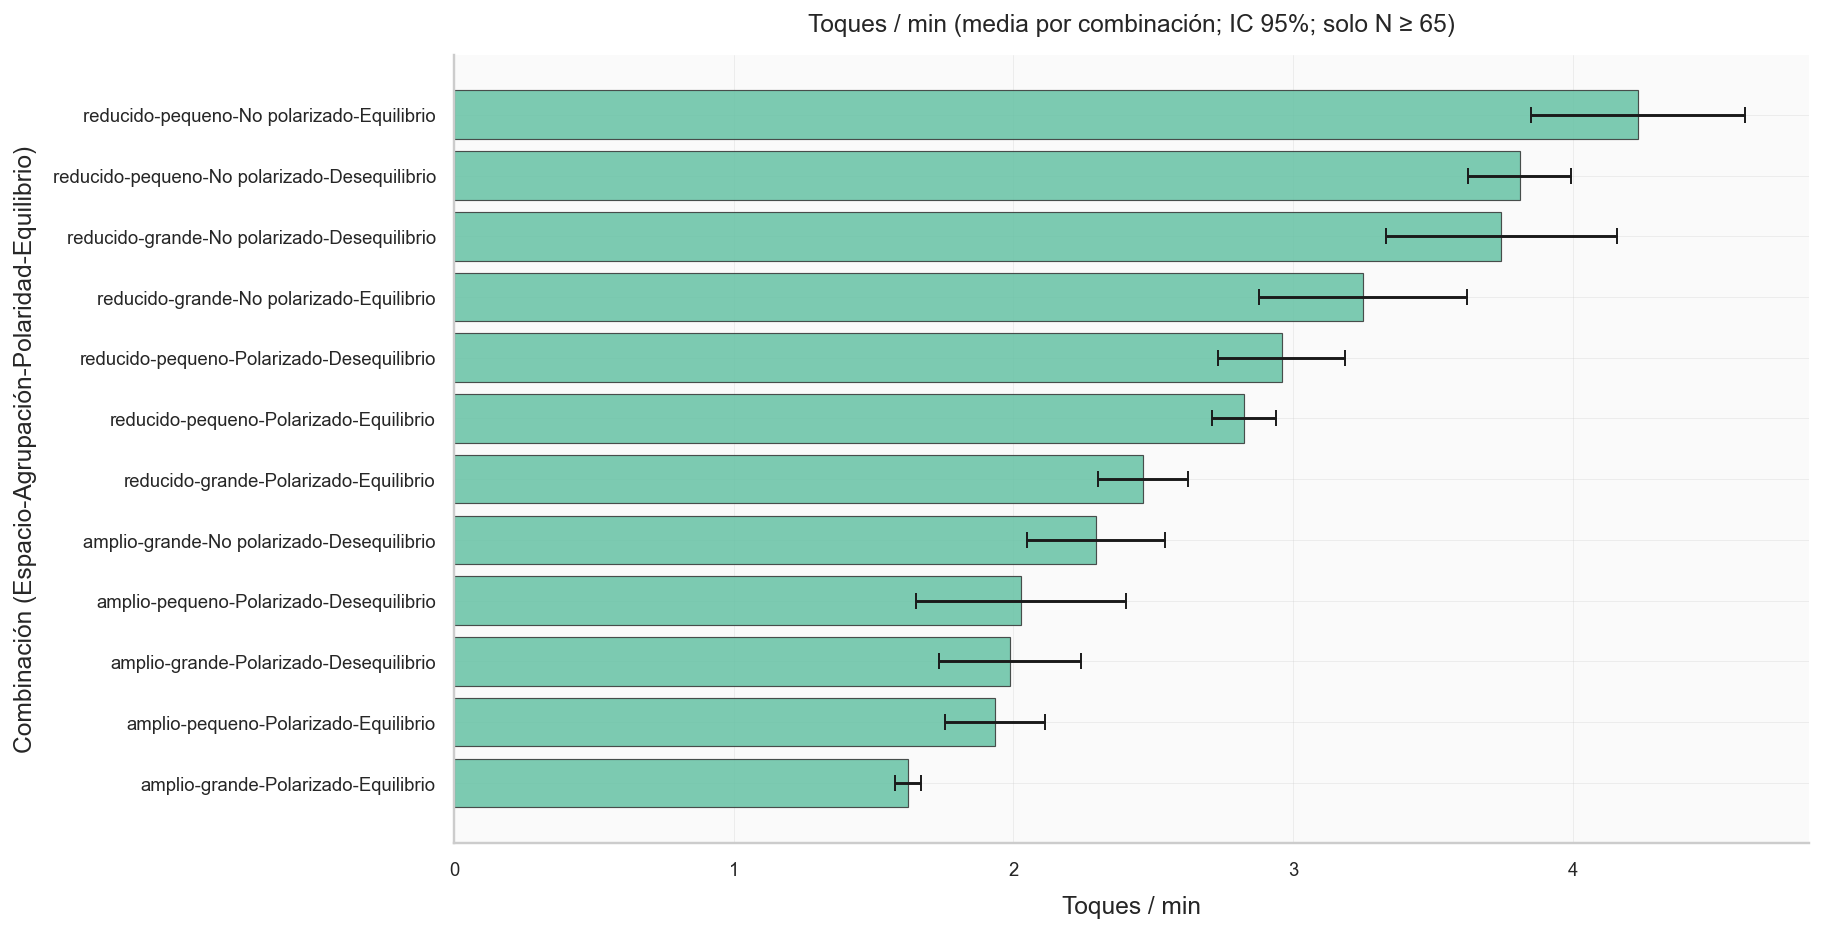

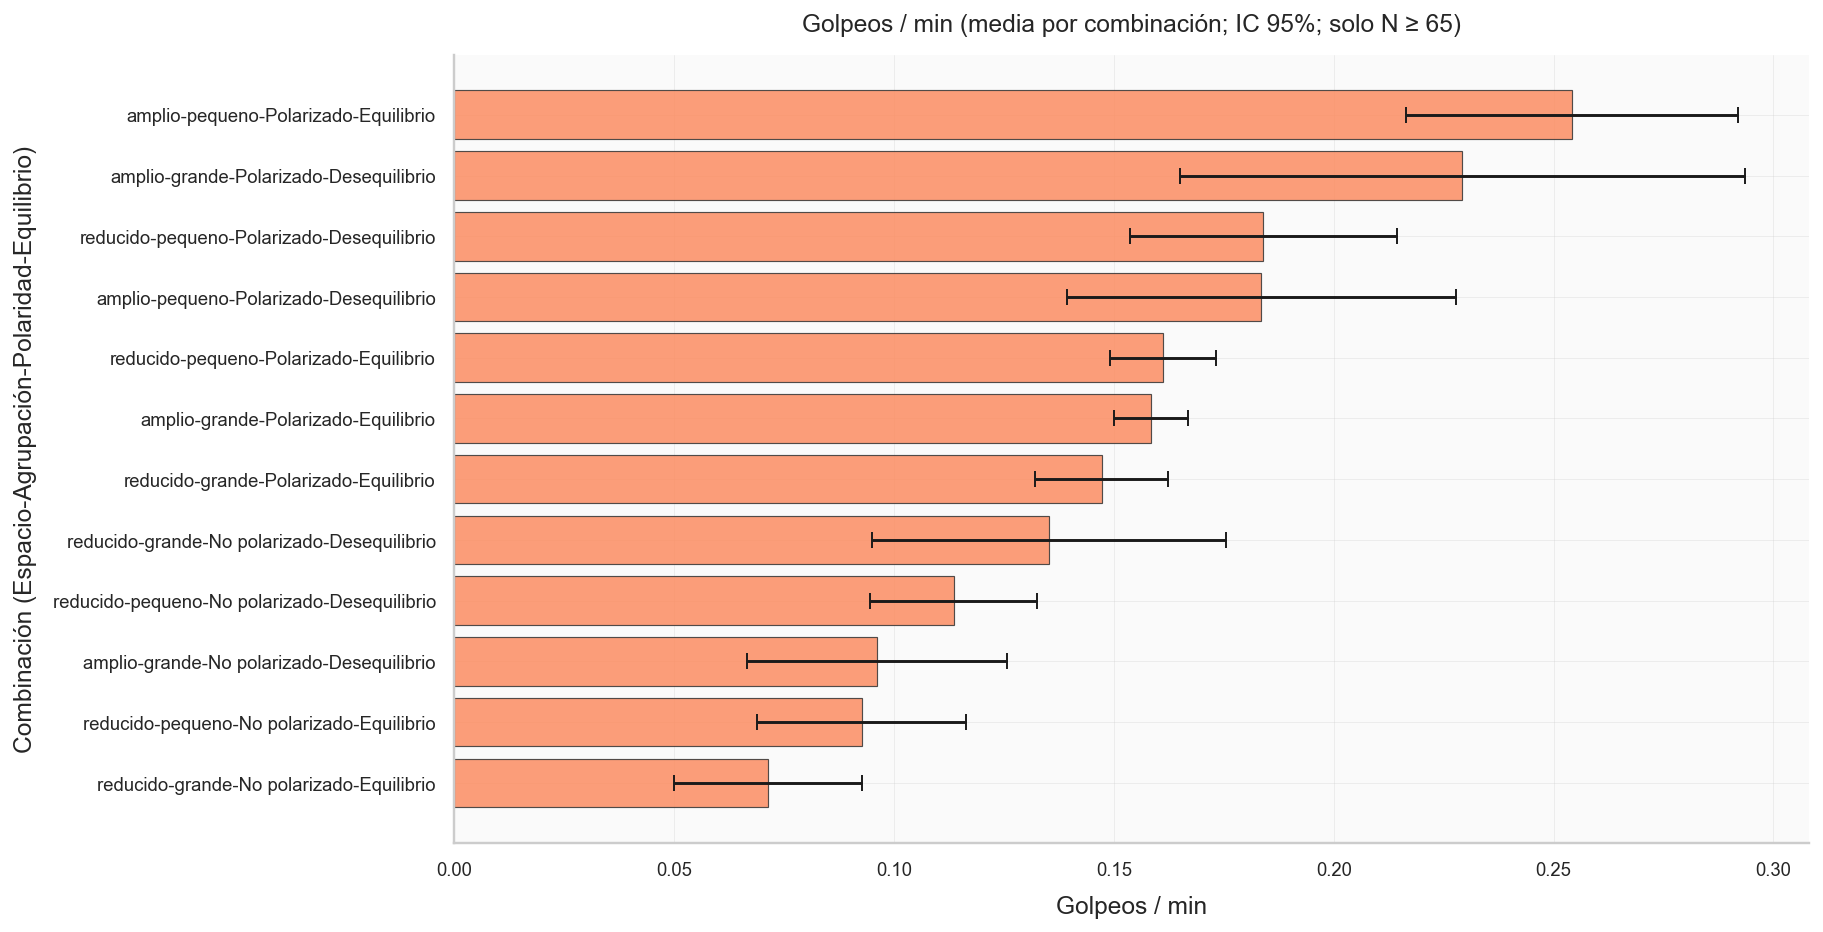

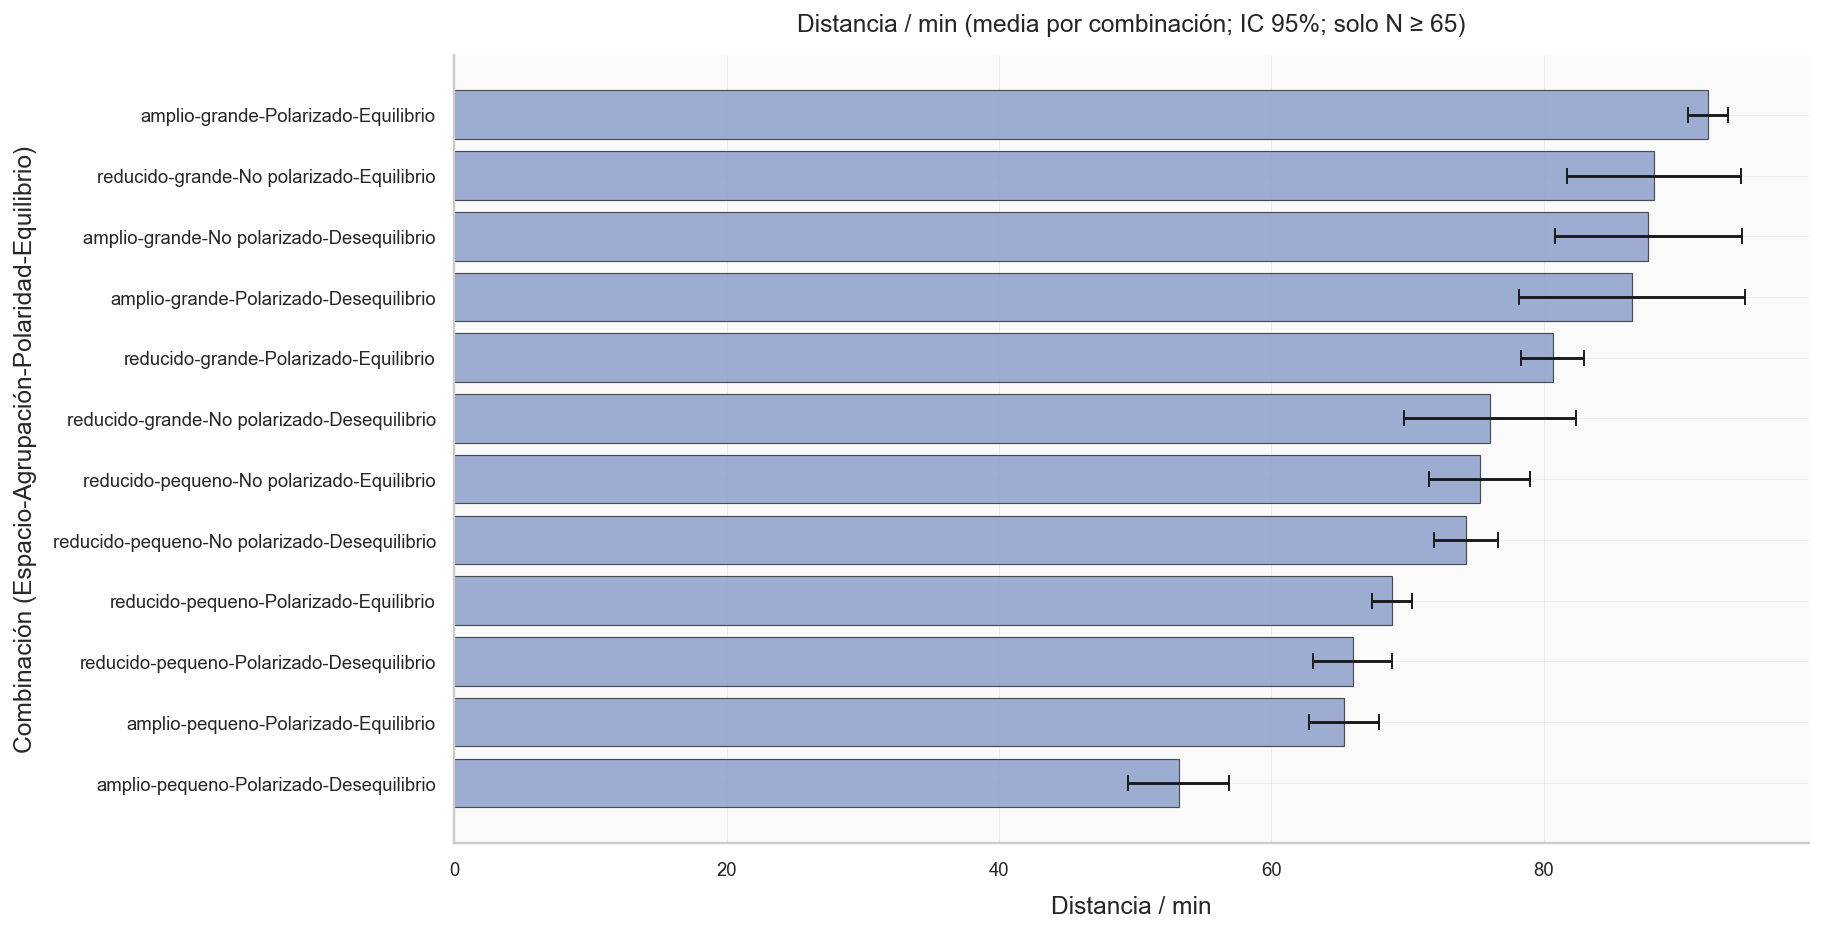

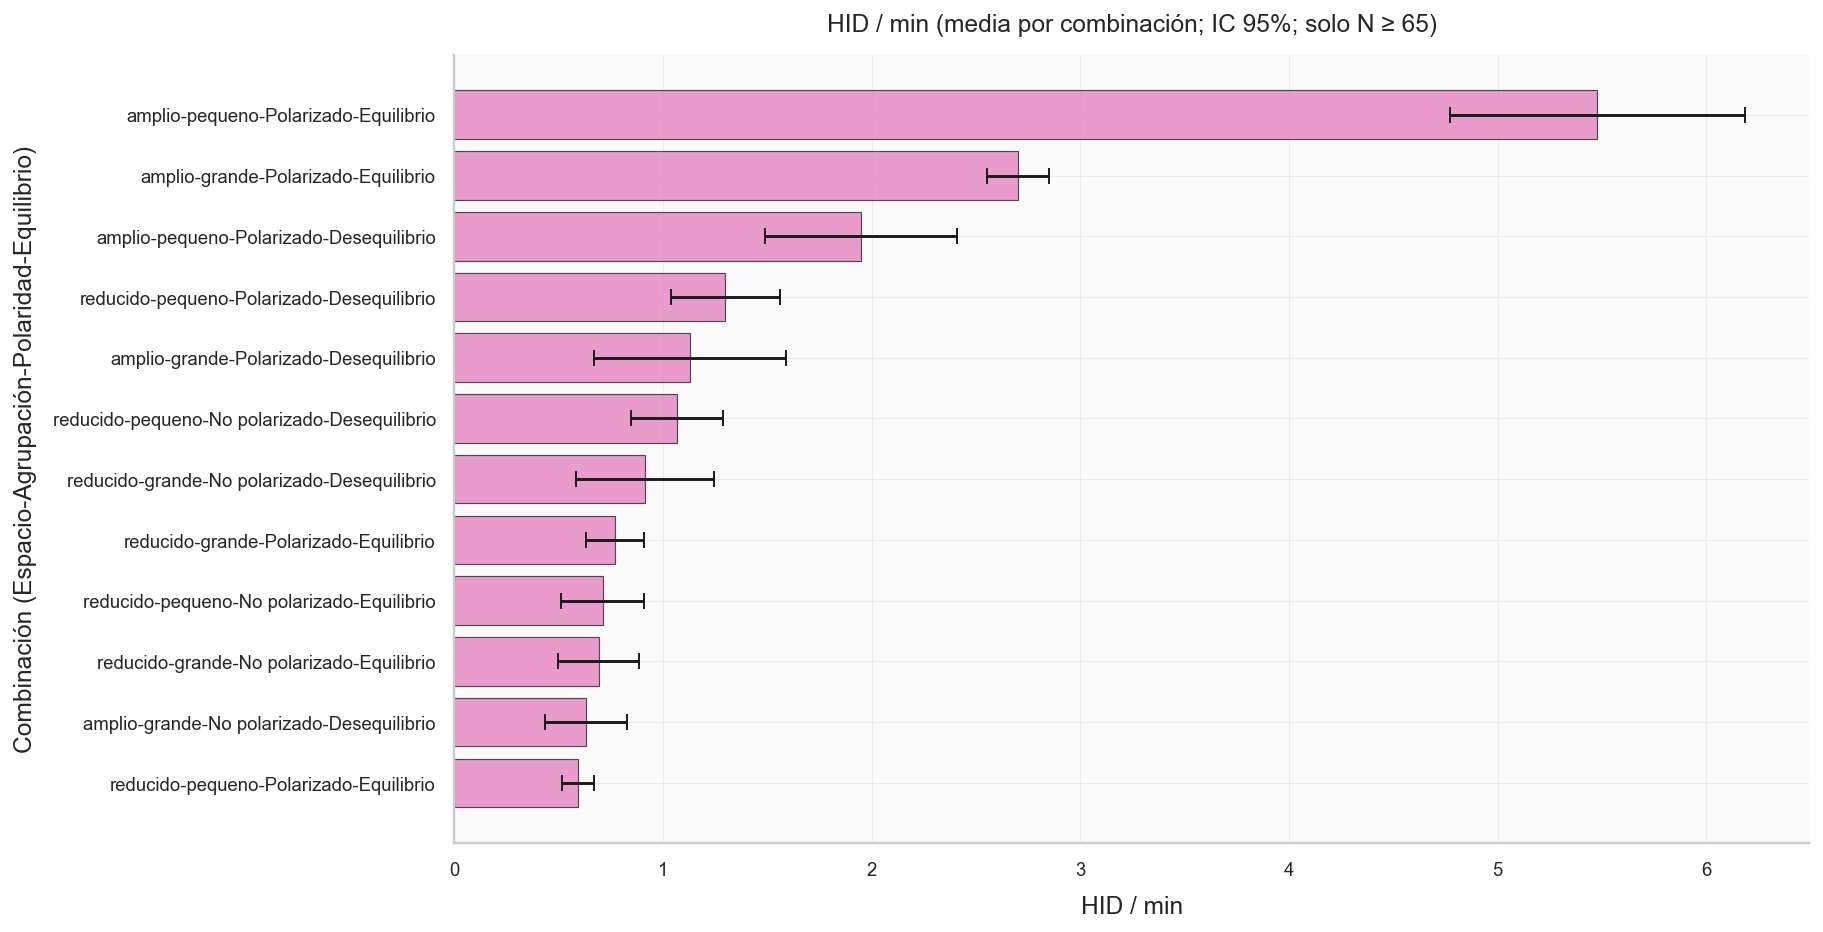

In [6]:
# ── Filtrar combinaciones con N suficiente ──────────────────
N_MIN = 65

conteo_combo = df["Combinacion"].value_counts()
combos_validas = conteo_combo[conteo_combo >= N_MIN].index
combos_excluidas = conteo_combo[conteo_combo < N_MIN].sort_values(ascending=True)

df_filtrado = df[df["Combinacion"].isin(combos_validas)].copy()

print(f"Filtro aplicado: N >= {N_MIN}")
print(f"  Combinaciones totales:   {conteo_combo.shape[0]}")
print(f"  Combinaciones retenidas: {len(combos_validas)}")
print(f"  Observaciones retenidas: {df_filtrado.shape[0]} / {df.shape[0]}")
if len(combos_excluidas) > 0:
    print("\nCombinaciones excluidas (N < {0}):".format(N_MIN))
    print(combos_excluidas.to_string())


def plot_vd_por_combinacion(df_in: pd.DataFrame, vd: str, label: str, color=None) -> None:
    """Gráfico horizontal de media por combinación con IC 95% (escala original)."""
    resumen = (
        df_in.groupby("Combinacion")[vd]
        .agg(["mean", "std", "count"])
        .rename(columns={"mean": "Media", "std": "SD", "count": "N"})
        .reset_index()
    )
    resumen["N"] = resumen["N"].astype(int)
    resumen["SE"] = resumen["SD"] / np.sqrt(resumen["N"].clip(lower=1))

    # IC 95% usando t de Student
    resumen["tcrit"] = stats.t.ppf(0.975, resumen["N"] - 1)
    resumen["IC95"] = resumen["tcrit"] * resumen["SE"]

    # Etiqueta de visualización (p.ej., "No_polarizado" -> "No polarizado")
    resumen["Combinacion_display"] = resumen["Combinacion"].str.replace("_", " ", regex=False)

    # Orden para barh (menor→mayor)
    resumen = resumen.sort_values("Media", ascending=True)

    fig_h = max(5.2, 0.42 * resumen.shape[0] + 1.8)
    fig, ax = plt.subplots(figsize=(13.2, fig_h))

    y = np.arange(resumen.shape[0])
    ax.barh(
        y,
        resumen["Media"].to_numpy(),
        xerr=resumen["IC95"].to_numpy(),
        capsize=4,
        color=color,
        alpha=0.85,
        edgecolor="#333333",
        linewidth=0.6,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(resumen["Combinacion_display"], fontsize=9.5)

    ax.set_title(f"{label} (media por combinación; IC 95%; solo N ≥ {N_MIN})")
    ax.set_xlabel(label)
    ax.set_ylabel("Combinación (Espacio-Agrupación-Polaridad-Equilibrio)")

    plt.tight_layout()
    plt.show()


# ── Generar un gráfico por VD ───────────────────────────────
for vd in vd_cols:
    plot_vd_por_combinacion(
        df_filtrado,
        vd=vd,
        label=vd_to_label.get(vd, vd),
        color=vd_to_color.get(vd, None),
    )

---
## 3. Heatmap de medias normalizadas (combinaciones × VD)

Para poder comparar las VD entre sí (tienen escalas muy diferentes), estandarizamos las medias de cada VD a **z-scores** y representamos un heatmap. Las filas se ordenan por la media global de z-scores, de forma que las combinaciones "mejores" (más rendimiento) quedan arriba.

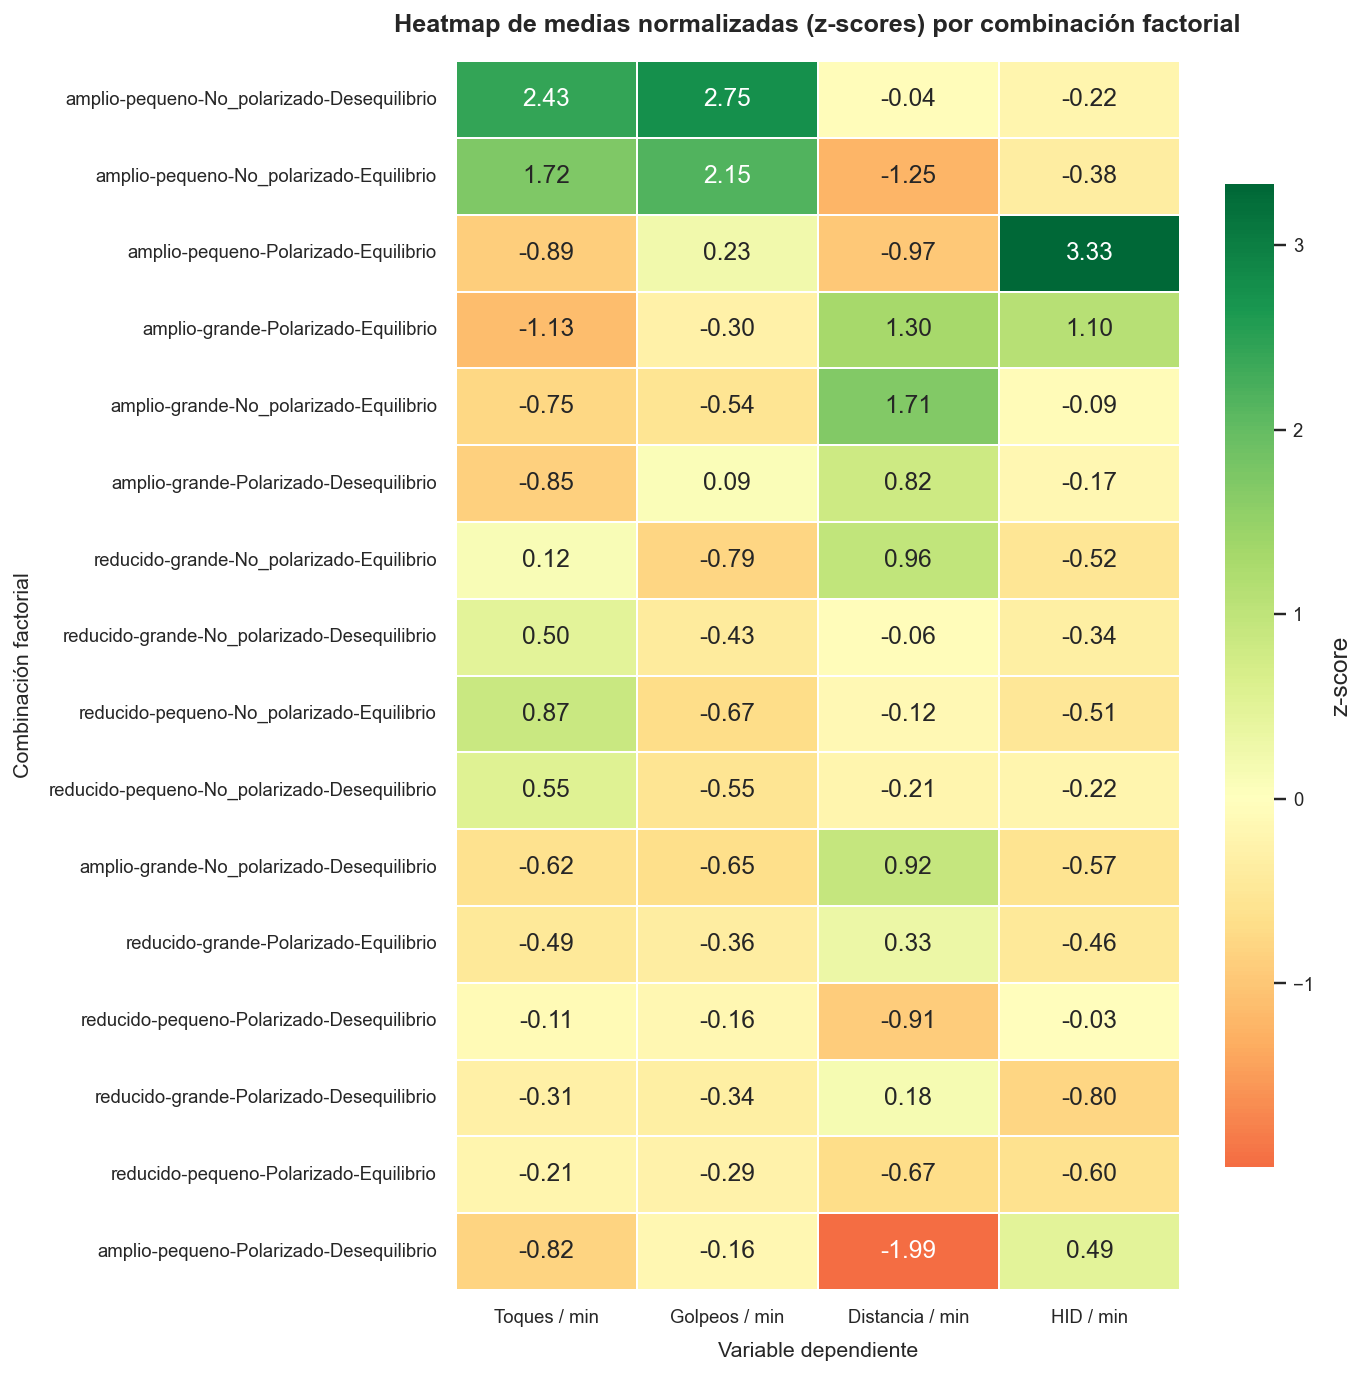

In [18]:
# ── Calcular z-scores de las medias por combinación ──────
medias_simple = df.groupby("Combinacion")[vd_cols].mean()

# Estandarizar dentro de cada VD
z_scores = medias_simple.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
z_scores.columns = vd_labels

# Media global de z-scores para ordenar
z_scores["Media global z"] = z_scores.mean(axis=1)
z_scores = z_scores.sort_values("Media global z", ascending=False)

# ── Heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    z_scores[vd_labels],
    annot=True, fmt=".2f",
    cmap="RdYlGn", center=0,
    linewidths=0.8, linecolor="white",
    cbar_kws={"label": "z-score", "shrink": 0.8},
    ax=ax,
)

ax.set_title("Heatmap de medias normalizadas (z-scores) por combinación factorial",
             fontsize=13, fontweight="bold", pad=15)
ax.set_ylabel("Combinación factorial", fontsize=11)
ax.set_xlabel("Variable dependiente", fontsize=11)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

**Interpretación:** El heatmap permite identificar de un vistazo los perfiles de rendimiento de cada combinación. Los tonos verdes indican valores por encima de la media (z > 0), los rojos por debajo (z < 0). Las combinaciones situadas en la parte superior tienen un rendimiento global más elevado. Se aprecia si algún factor domina el ranking o si las combinaciones extremas comparten niveles comunes en alguna VI.

---
## 4. VD con inflación de ceros: Golpeos/min y HID/min

Las variables **Golpeos +15 m/s / min** y **HID / min** presentan una proporción relevante de observaciones con valor **cero**, lo que las distingue de Toques/min y Distancia/min. Analizar solo la media global enmascara dos fenómenos distintos:

1. **Probabilidad de ocurrencia** (% de observaciones > 0): ¿la combinación factorial *genera* el evento?
2. **Intensidad condicionada** (media solo de valores > 0): cuando el evento ocurre, ¿con qué magnitud?

Esta descomposición es coherente con un futuro modelado mediante **modelos hurdle o zero-inflated** en la fase de modelización.

In [19]:
# ── VD con inflación de ceros ─────────────────────────────
vd_zeros = ["Golpeos +15 m/s / min", "High Intensity Distance (20 km/h) / min"]
vd_zeros_labels = ["Golpeos / min", "HID / min"]

# ── Tabla descriptiva: % ceros + media condicionada ──────
filas = []
for comb, grp in df.groupby("Combinacion"):
    fila = {"Combinacion": comb, "N": len(grp)}
    for vd, label in zip(vd_zeros, vd_zeros_labels):
        valores = grp[vd].dropna()
        n_total = len(valores)
        n_ceros = (valores == 0).sum()
        n_pos = (valores > 0).sum()
        pct_ceros = n_ceros / n_total * 100 if n_total > 0 else np.nan
        media_global = valores.mean()
        media_cond = valores[valores > 0].mean() if n_pos > 0 else np.nan
        
        fila[f"{label} — % ceros"] = round(pct_ceros, 1)
        fila[f"{label} — Media global"] = round(media_global, 4)
        fila[f"{label} — Media cond. (>0)"] = round(media_cond, 4)
        fila[f"{label} — N>0"] = int(n_pos)
    filas.append(fila)

df_zeros = pd.DataFrame(filas).set_index("Combinacion")
df_zeros = df_zeros.reindex(z_scores.index)  # Mismo orden que heatmap

# ── Mostrar tabla ─────────────────────────────────────────
from IPython.display import display, Markdown

display(Markdown("### Tabla: inflación de ceros por combinación factorial"))
display(Markdown("*Ordenada por media global de z-scores (misma que el heatmap)*"))

cols_pct = [c for c in df_zeros.columns if "% ceros" in c]
cols_media_cond = [c for c in df_zeros.columns if "Media cond" in c]

display(
    df_zeros.style
    .format(precision=2)
    .background_gradient(subset=cols_pct, cmap="Reds", axis=0)
    .background_gradient(subset=cols_media_cond, cmap="YlGnBu", axis=0)
)

### Tabla: inflación de ceros por combinación factorial

*Ordenada por media global de z-scores (misma que el heatmap)*

,N,Golpeos / min — % ceros,Golpeos / min — Media global,Golpeos / min — Media cond. (>0),Golpeos / min — N>0,HID / min — % ceros,HID / min — Media global,HID / min — Media cond. (>0),HID / min — N>0
Combinacion,,,,,,,,,
amplio-pequeno-No_polarizado-Desequilibrio,23,26.10,0.71,0.96,17,30.40,1.07,1.53,16
amplio-pequeno-No_polarizado-Equilibrio,23,13.00,0.60,0.69,20,21.70,0.87,1.11,18
amplio-pequeno-Polarizado-Equilibrio,370,21.60,0.25,0.32,290,14.60,5.48,6.41,316
amplio-grande-Polarizado-Equilibrio,1461,19.20,0.16,0.20,1180,16.10,2.70,3.22,1226
amplio-grande-No_polarizado-Equilibrio,55,34.50,0.12,0.18,36,29.10,1.23,1.74,39
amplio-grande-Polarizado-Desequilibrio,65,20.00,0.23,0.29,52,30.80,1.13,1.63,45
reducido-grande-No_polarizado-Equilibrio,124,61.30,0.07,0.18,48,46.00,0.69,1.28,67
reducido-grande-No_polarizado-Desequilibrio,106,51.90,0.14,0.28,51,42.50,0.91,1.59,61
reducido-pequeno-No_polarizado-Equilibrio,122,50.80,0.09,0.19,60,40.20,0.71,1.19,73


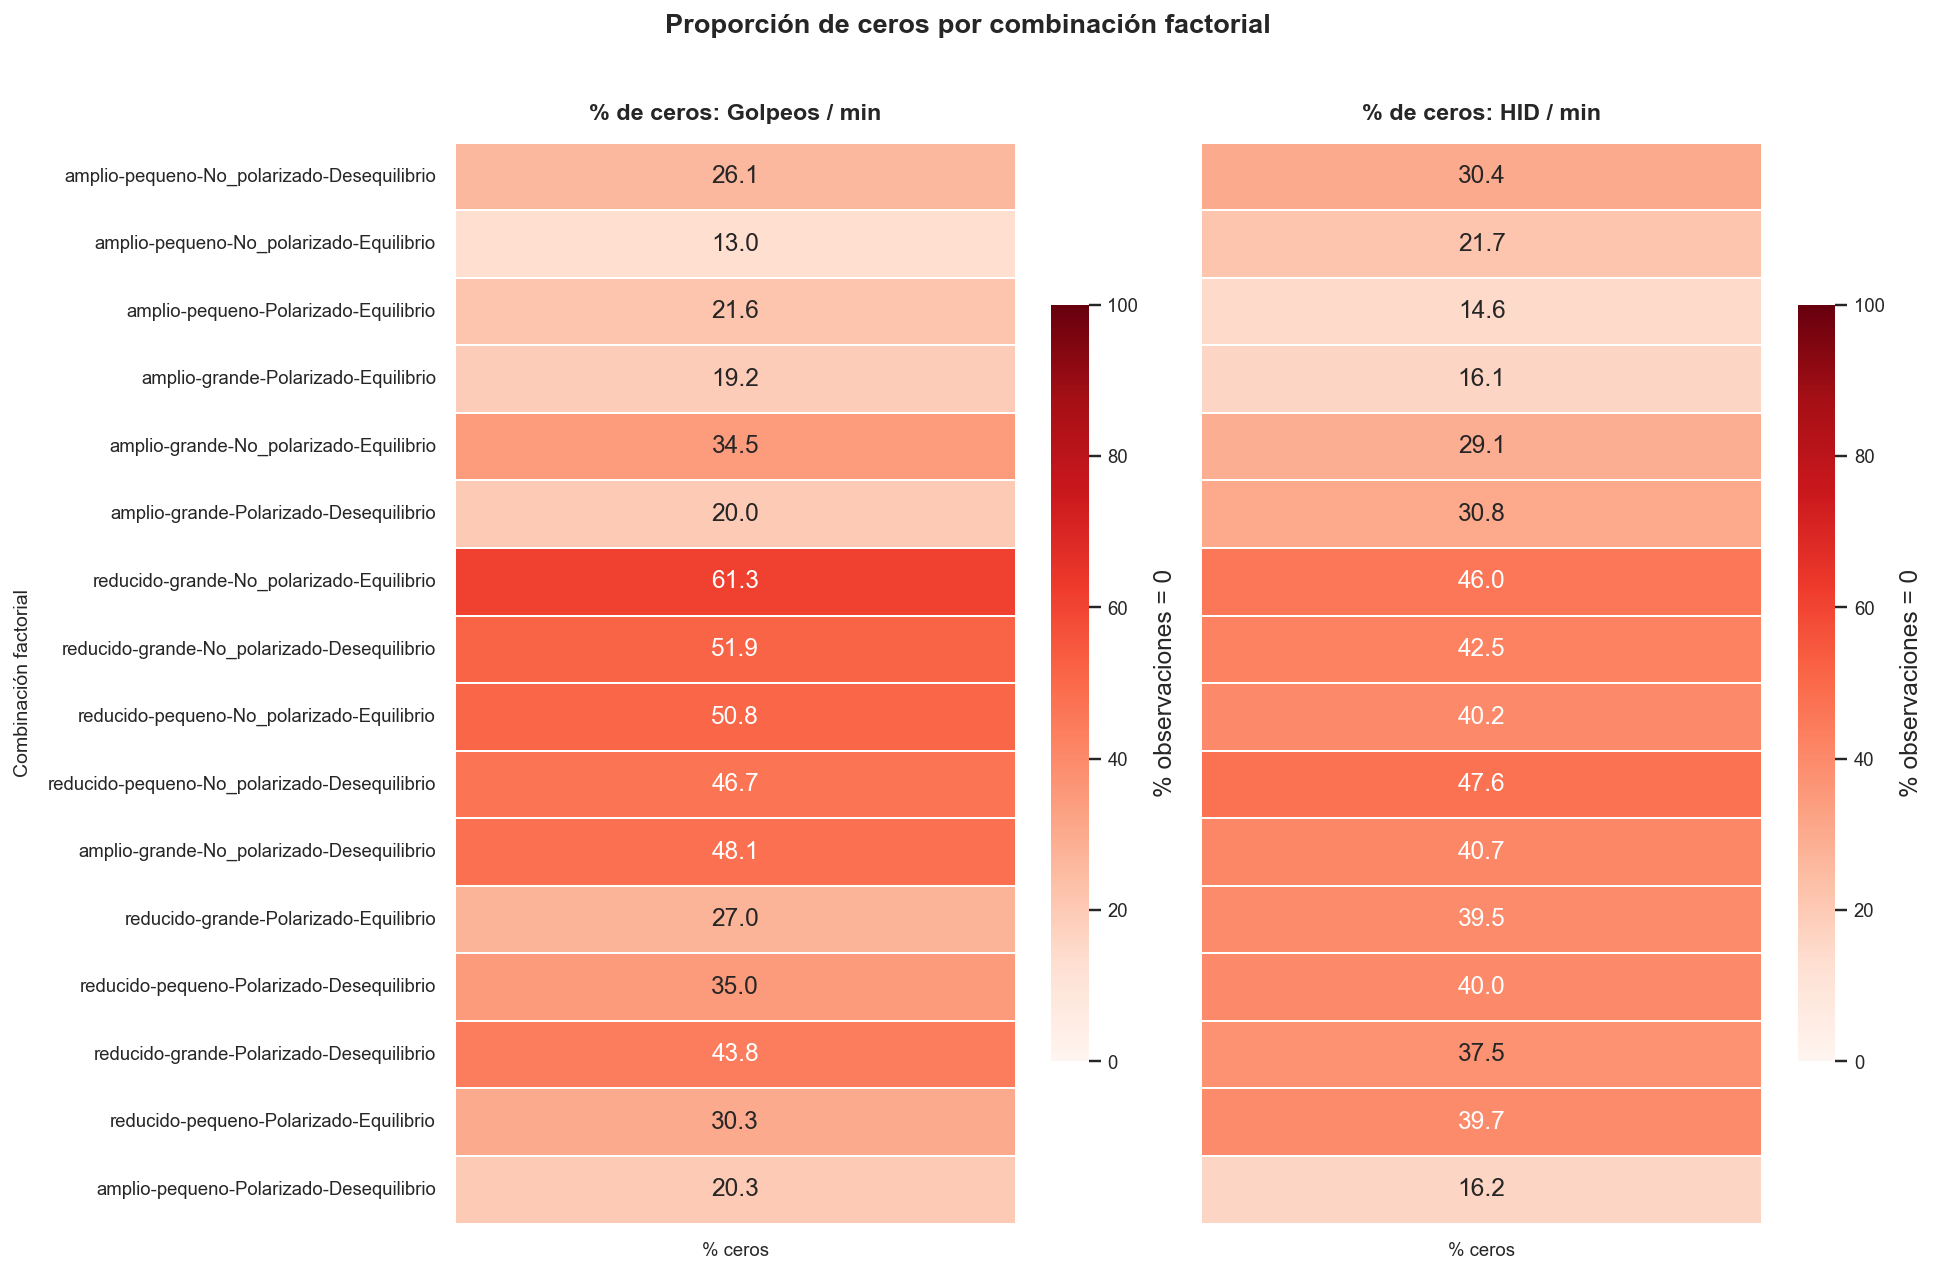

In [20]:
# ── Heatmap doble: % ceros por combinación ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 9), sharey=True)

for ax, (vd, label) in zip(axes, zip(vd_zeros, vd_zeros_labels)):
    col_pct = f"{label} — % ceros"
    datos = df_zeros[[col_pct]].copy()
    datos.columns = ["% ceros"]
    
    sns.heatmap(
        datos, annot=True, fmt=".1f",
        cmap="Reds", vmin=0, vmax=100,
        linewidths=0.8, linecolor="white",
        cbar_kws={"label": "% observaciones = 0", "shrink": 0.7},
        ax=ax,
    )
    ax.set_title(f"% de ceros: {label}", fontsize=12, fontweight="bold")
    ax.set_ylabel("" if ax != axes[0] else "Combinación factorial", fontsize=10)
    ax.tick_params(axis="y", rotation=0)

plt.suptitle("Proporción de ceros por combinación factorial",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

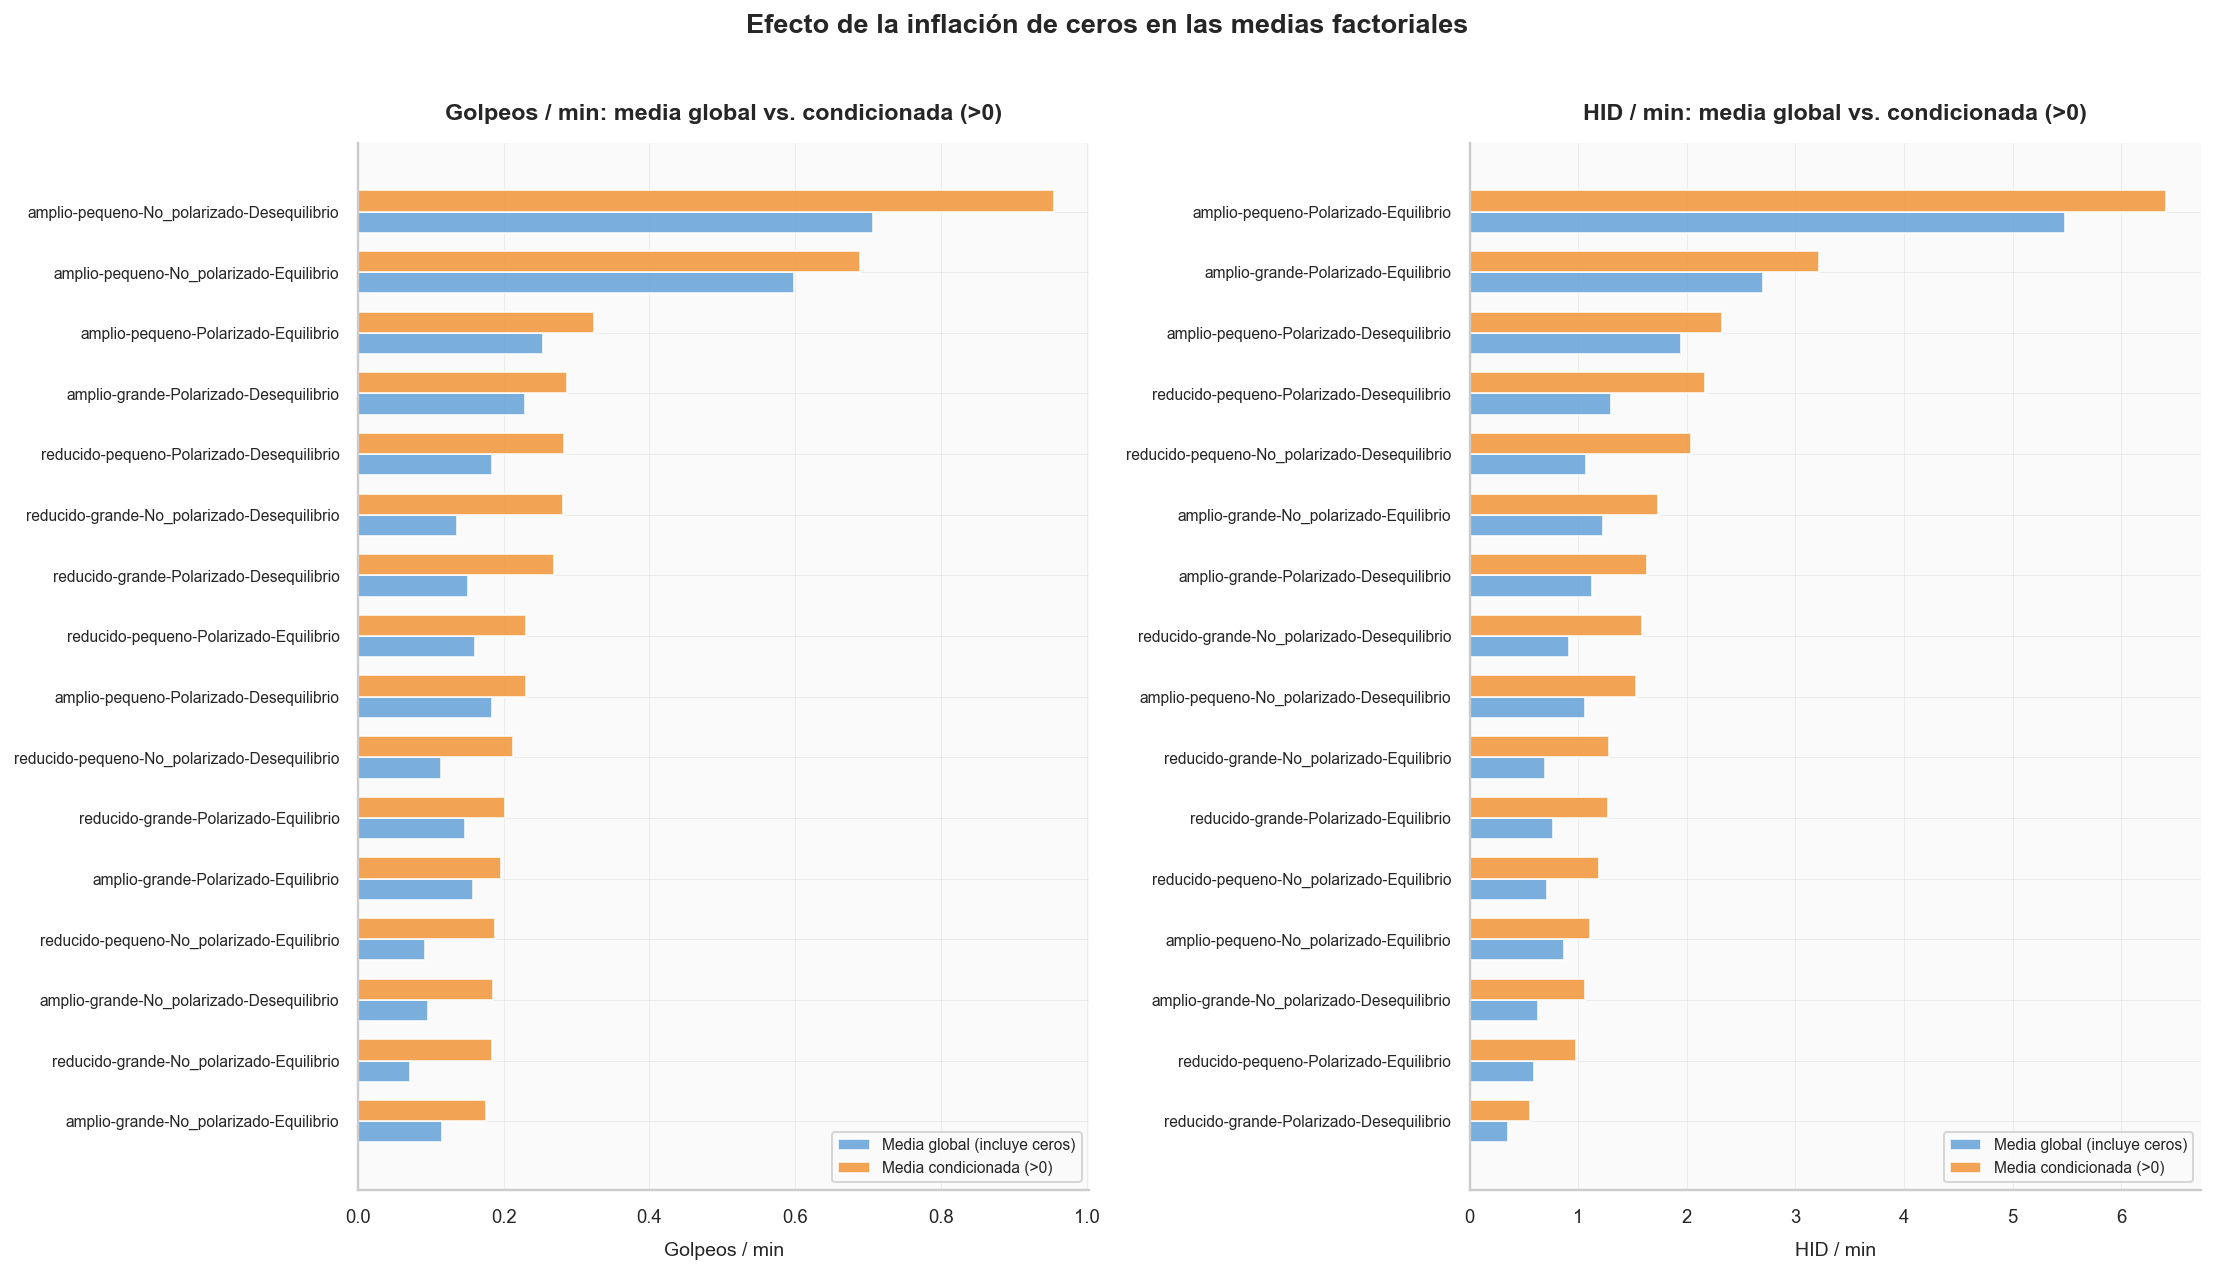

Ratio media condicionada / media global (cuánto se amplifica al excluir ceros):

▸ Golpeos / min:
  Ratio medio:  1.60x
  Ratio rango:  1.15x – 2.58x

▸ HID / min:
  Ratio medio:  1.53x
  Ratio rango:  1.17x – 1.91x


In [21]:
# ── Comparación: media global vs. media condicionada (>0) ─
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

for ax, (vd, label) in zip(axes, zip(vd_zeros, vd_zeros_labels)):
    col_global = f"{label} — Media global"
    col_cond = f"{label} — Media cond. (>0)"
    
    datos_plot = df_zeros[[col_global, col_cond]].copy()
    datos_plot.columns = ["Media global", "Media cond. (>0)"]
    datos_plot = datos_plot.sort_values("Media cond. (>0)", ascending=True)
    
    y_pos = np.arange(len(datos_plot))
    alto = 0.35
    
    ax.barh(y_pos - alto/2, datos_plot["Media global"], height=alto,
            color="#5A9BD5", alpha=0.8, label="Media global (incluye ceros)")
    ax.barh(y_pos + alto/2, datos_plot["Media cond. (>0)"], height=alto,
            color="#F28E2B", alpha=0.8, label="Media condicionada (>0)")
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(datos_plot.index, fontsize=8)
    ax.set_xlabel(label, fontsize=10)
    ax.set_title(f"{label}: media global vs. condicionada (>0)",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("Efecto de la inflación de ceros en las medias factoriales",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Ratio de amplificación: media_cond / media_global ────
print("Ratio media condicionada / media global (cuánto se amplifica al excluir ceros):")
print("=" * 70)
for vd, label in zip(vd_zeros, vd_zeros_labels):
    col_g = f"{label} — Media global"
    col_c = f"{label} — Media cond. (>0)"
    ratio = (df_zeros[col_c] / df_zeros[col_g]).replace([np.inf, -np.inf], np.nan)
    print(f"\n▸ {label}:")
    print(f"  Ratio medio:  {ratio.mean():.2f}x")
    print(f"  Ratio rango:  {ratio.min():.2f}x – {ratio.max():.2f}x")

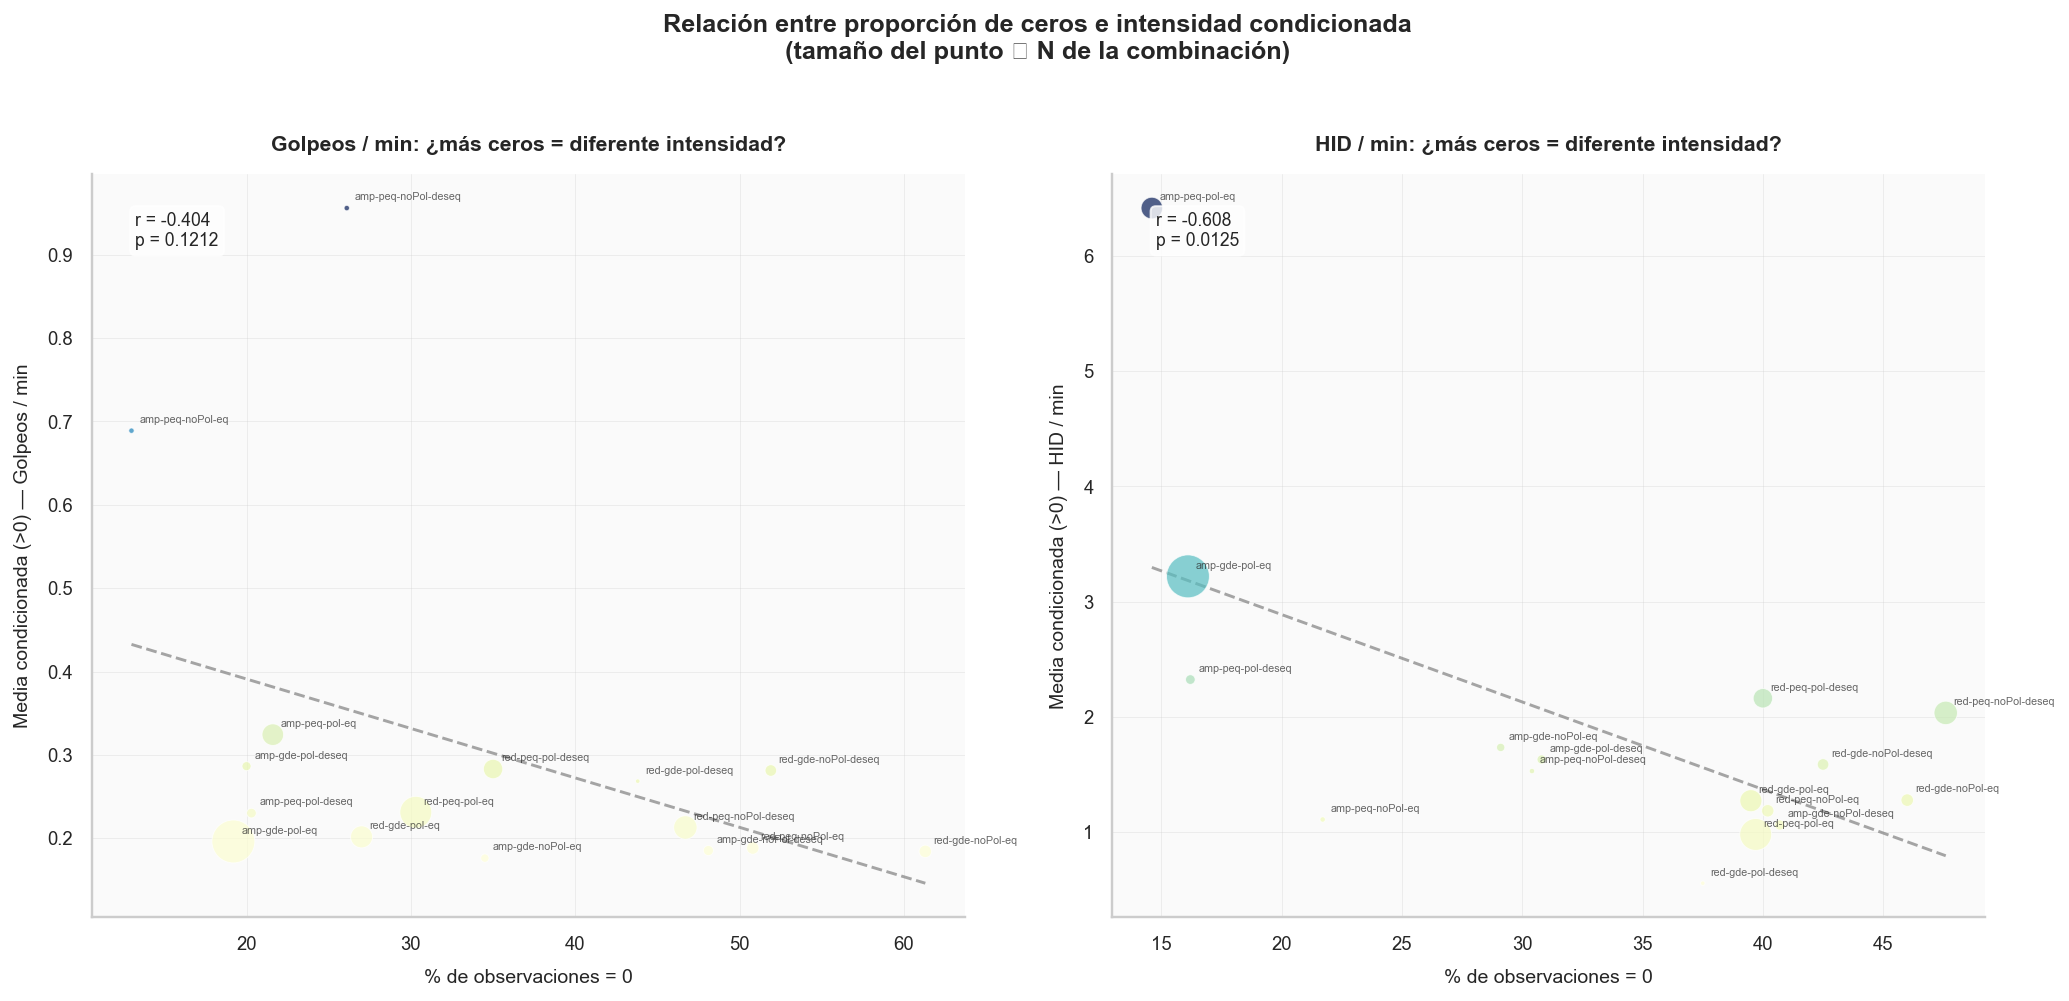

In [22]:
# ── Scatter: % ceros vs. media condicionada (>0) ─────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, (vd, label) in zip(axes, zip(vd_zeros, vd_zeros_labels)):
    col_pct = f"{label} — % ceros"
    col_cond = f"{label} — Media cond. (>0)"
    col_n = f"{label} — N>0"
    
    x = df_zeros[col_pct].values
    y = df_zeros[col_cond].values
    sizes = df_zeros["N"].values
    
    # Filtrar NaN
    mask = ~(np.isnan(x) | np.isnan(y))
    x_c, y_c = x[mask], y[mask]
    s_c = sizes[mask]
    nombres = df_zeros.index[mask]
    
    # Scatter con tamaño proporcional a N
    scatter = ax.scatter(x_c, y_c, s=s_c / 3, alpha=0.7,
                         c=y_c, cmap="YlGnBu", edgecolors="white",
                         linewidths=0.5, zorder=3)
    
    # Etiquetas
    for xi, yi, nombre in zip(x_c, y_c, nombres):
        short = nombre.replace("No_polarizado", "noPol").replace(
            "Polarizado", "pol").replace(
            "Desequilibrio", "deseq").replace(
            "Equilibrio", "eq").replace(
            "reducido", "red").replace(
            "amplio", "amp").replace(
            "grande", "gde").replace(
            "pequeno", "peq")
        ax.annotate(short, (xi, yi), fontsize=5.5, alpha=0.7,
                    xytext=(4, 4), textcoords="offset points")
    
    # Línea de tendencia
    if len(x_c) > 2:
        slope, intercept, r_val, p_val, _ = stats.linregress(x_c, y_c)
        x_line = np.linspace(x_c.min(), x_c.max(), 100)
        ax.plot(x_line, slope * x_line + intercept,
                "--", color="grey", alpha=0.7, linewidth=1.5, zorder=2)
        ax.text(0.05, 0.95,
                f"r = {r_val:.3f}\np = {p_val:.4f}",
                transform=ax.transAxes, fontsize=9, va="top",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    ax.set_xlabel(f"% de observaciones = 0", fontsize=10)
    ax.set_ylabel(f"Media condicionada (>0) — {label}", fontsize=10)
    ax.set_title(f"{label}: ¿más ceros = diferente intensidad?",
                 fontsize=11, fontweight="bold")
    ax.grid(alpha=0.3)

plt.suptitle("Relación entre proporción de ceros e intensidad condicionada\n"
             "(tamaño del punto ∝ N de la combinación)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:**

- **% de ceros:** Las combinaciones factoriales difieren notablemente en su probabilidad de generar golpeos de alta velocidad y metros a alta intensidad. Combinaciones con mayor % de ceros representan contextos de tarea donde estos eventos son más raros.
- **Media global vs. condicionada:** La brecha entre ambas medias indica cuánto se "diluye" el rendimiento real por la presencia de ceros. A mayor % de ceros, mayor distorsión de la media global respecto a la intensidad real cuando el evento sí ocurre.
- **Scatter % ceros vs. media condicionada:** Si no hay relación significativa, la ocurrencia y la intensidad son fenómenos independientes (un argumento fuerte a favor de modelos hurdle/two-part). Si hay relación negativa (más ceros → menor intensidad cuando ocurre), sugiere un efecto global de la combinación sobre ambas componentes.

---
## 5. Varianza intra-celda: homogeneidad de las combinaciones

Evaluamos la dispersión dentro de cada celda factorial. Un **coeficiente de variación (CV)** alto indica que la combinación produce resultados heterogéneos; un CV bajo sugiere un efecto más estable y predecible. Además, la relación media-varianza tiene implicaciones directas para la elección del modelo estadístico.

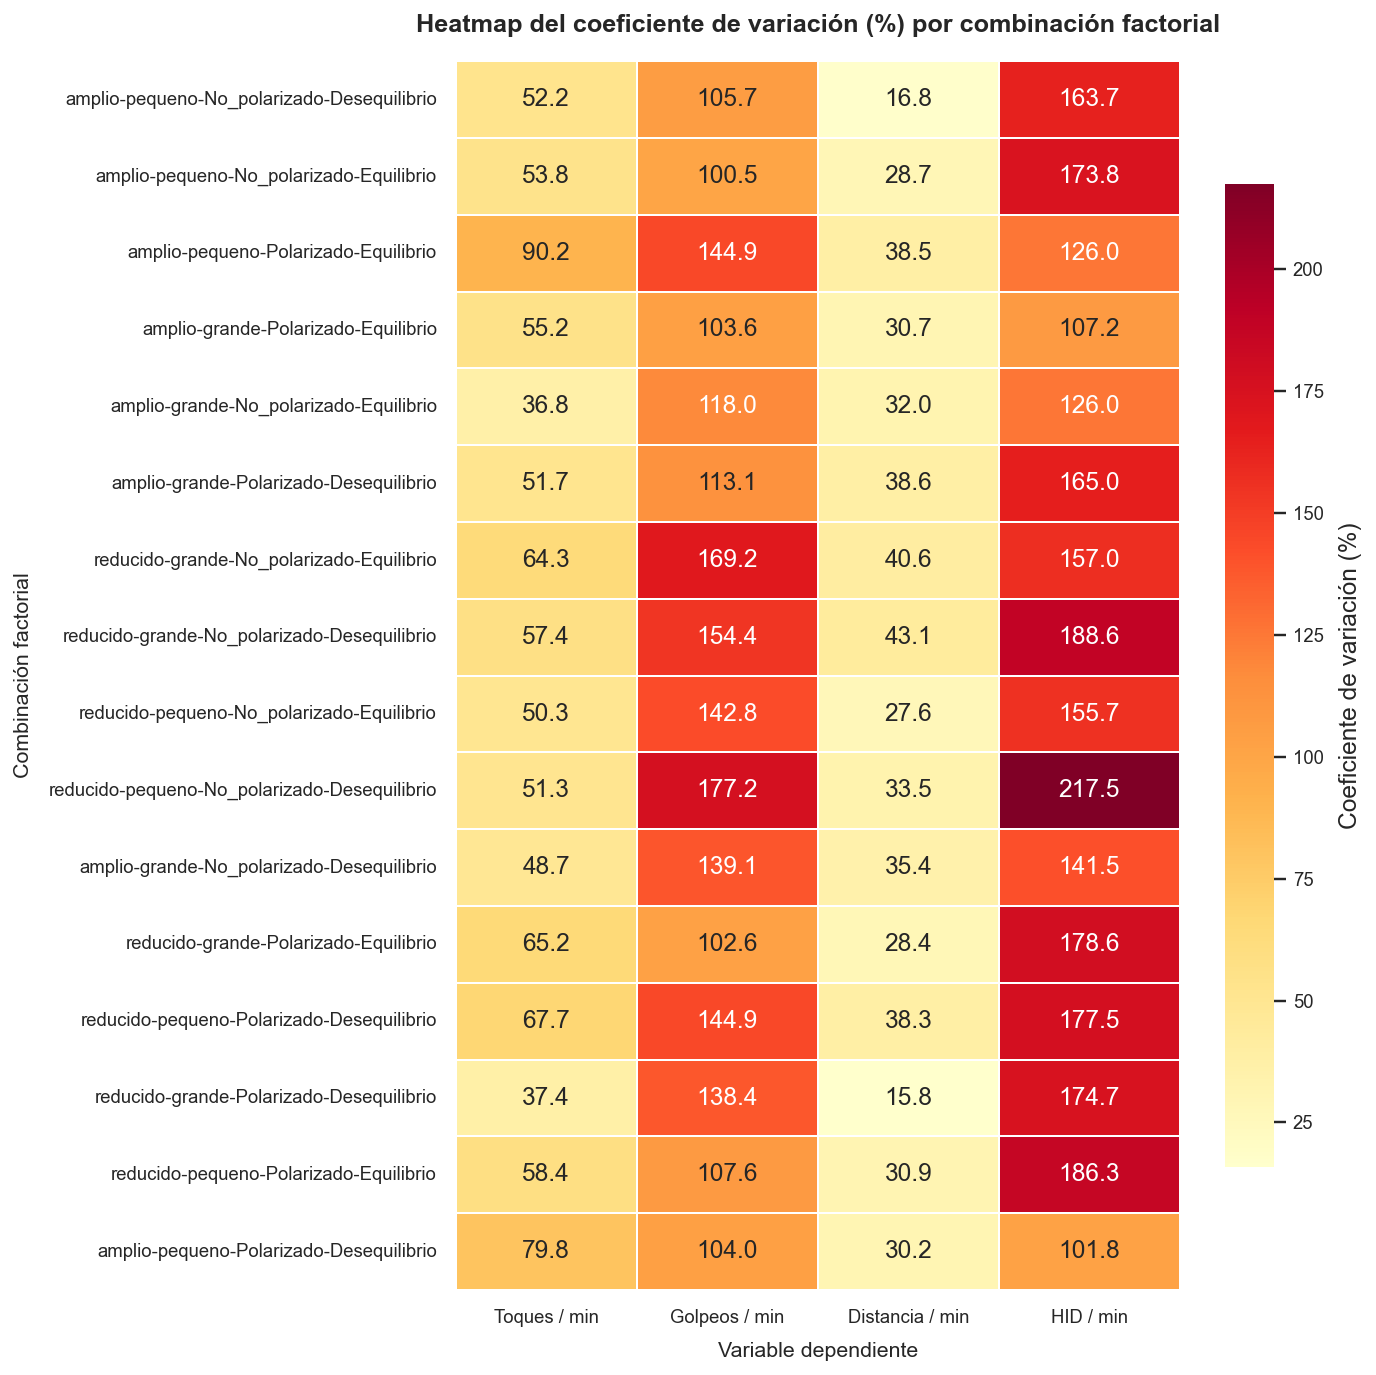

Resumen del CV (%) por VD:
       Toques / min  Golpeos / min  Distancia / min  HID / min
count          16.0           16.0             16.0       16.0
mean           57.5          129.1             31.8      158.8
std            13.8           25.3              7.7       31.4
min            36.8          100.5             15.8      101.8
25%            51.0          105.3             28.6      137.6
50%            54.5          128.2             31.4      164.3
75%            64.5          144.9             38.4      177.8
max            90.2          177.2             43.1      217.5


In [23]:
# ── Calcular SD y CV por combinación ─────────────────────
medias_celda = df.groupby("Combinacion")[vd_cols].mean()
sds_celda = df.groupby("Combinacion")[vd_cols].std()

# CV = SD / Media × 100 (en porcentaje)
cv_celda = (sds_celda / medias_celda * 100).replace([np.inf, -np.inf], np.nan)
cv_celda.columns = vd_labels

# Ordenar por media global de z-scores para consistencia
orden_combinaciones = z_scores.index.tolist()
cv_celda = cv_celda.reindex(orden_combinaciones)

# ── Heatmap de CV ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    cv_celda,
    annot=True, fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.8, linecolor="white",
    cbar_kws={"label": "Coeficiente de variación (%)", "shrink": 0.8},
    ax=ax,
)

ax.set_title("Heatmap del coeficiente de variación (%) por combinación factorial",
             fontsize=13, fontweight="bold", pad=15)
ax.set_ylabel("Combinación factorial", fontsize=11)
ax.set_xlabel("Variable dependiente", fontsize=11)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

# ── Resumen de homogeneidad ───────────────────────────────
print("Resumen del CV (%) por VD:")
print(cv_celda.describe().round(1).to_string())

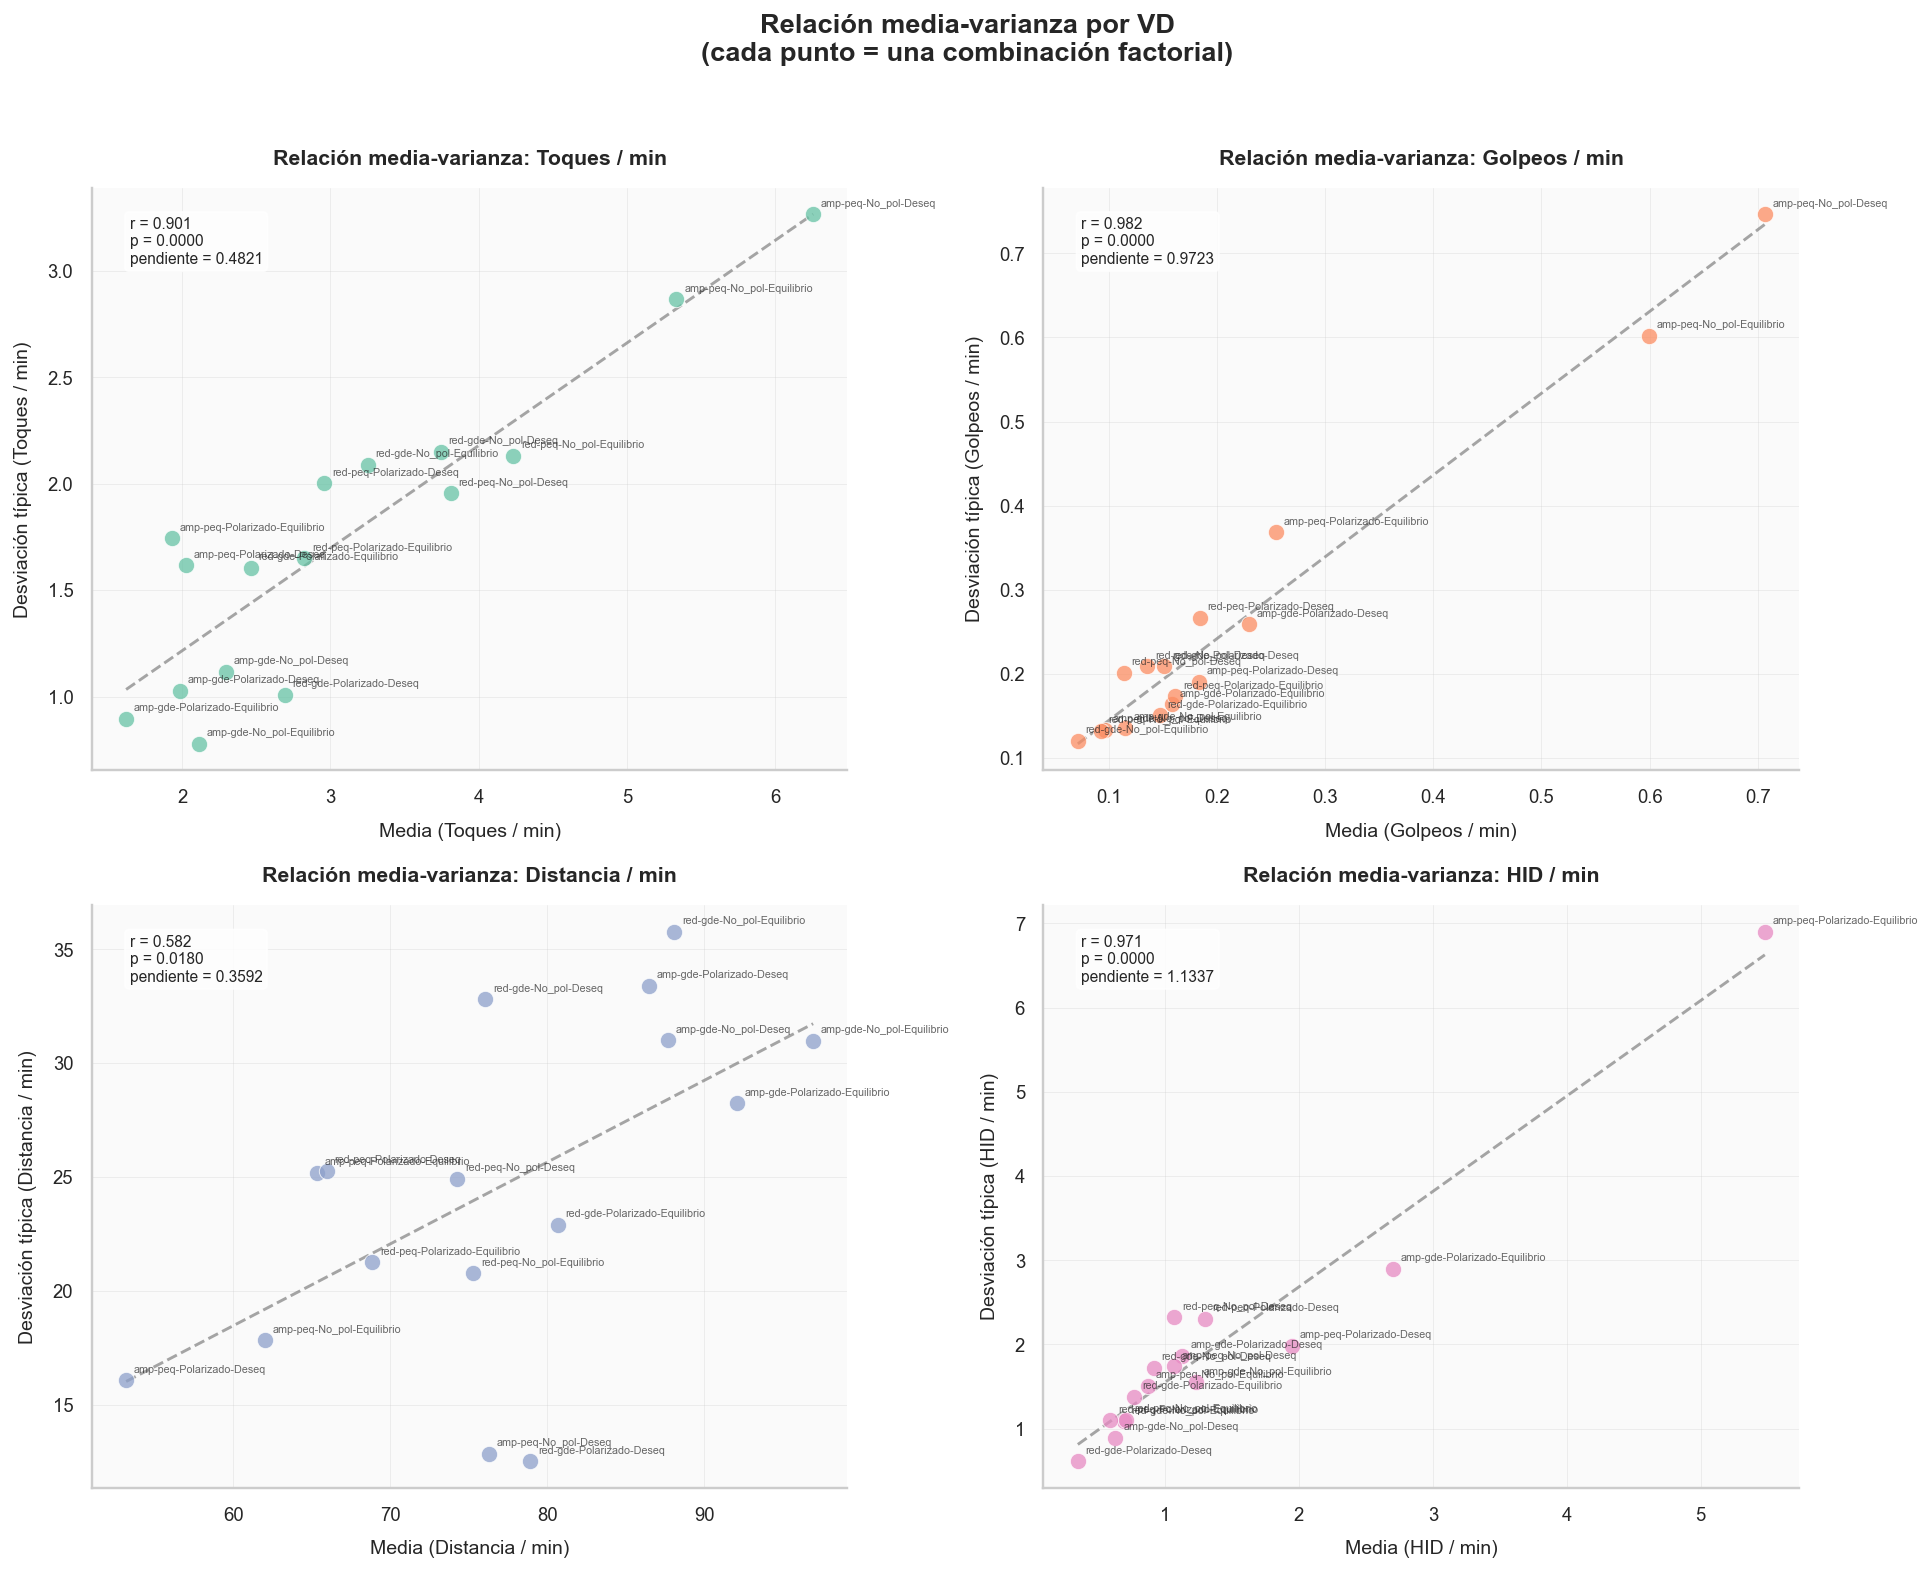

In [24]:
# ── Relación media-varianza: scatter con línea de tendencia ─
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.ravel()

for i, (vd, label) in enumerate(zip(vd_cols, vd_labels)):
    ax = axes[i]
    x = medias_celda[vd].values
    y = sds_celda[vd].values
    
    # Filtrar NaN
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean, y_clean = x[mask], y[mask]
    
    # Scatter
    ax.scatter(x_clean, y_clean, s=70, alpha=0.75,
               color=vd_to_color[vd], edgecolors="white", linewidths=0.5,
               zorder=3)
    
    # Etiquetas de cada punto
    nombres = medias_celda.index[mask]
    for xi, yi, nombre in zip(x_clean, y_clean, nombres):
        # Acortar el nombre para que quepa
        short = nombre.replace("no polarizado", "noPol").replace(
            "polarizado", "pol").replace(
            "desequilibrio", "deseq").replace(
            "equilibrio", "eq").replace(
            "reducido", "red").replace(
            "amplio", "amp").replace(
            "grande", "gde").replace(
            "pequeño", "peq").replace(
            "pequeno", "peq")
        ax.annotate(short, (xi, yi), fontsize=5.5, alpha=0.7,
                    xytext=(4, 4), textcoords="offset points")
    
    # Línea de tendencia
    if len(x_clean) > 2:
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
        x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
        ax.plot(x_line, slope * x_line + intercept,
                "--", color="grey", alpha=0.7, linewidth=1.5, zorder=2)
        ax.text(0.05, 0.95,
                f"r = {r_value:.3f}\np = {p_value:.4f}\npendiente = {slope:.4f}",
                transform=ax.transAxes, fontsize=8, va="top",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    ax.set_xlabel(f"Media ({label})", fontsize=10)
    ax.set_ylabel(f"Desviación típica ({label})", fontsize=10)
    ax.set_title(f"Relación media-varianza: {label}", fontsize=11, fontweight="bold")

plt.suptitle("Relación media-varianza por VD\n"
             "(cada punto = una combinación factorial)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** 

- **Heatmap de CV:** Permite identificar las combinaciones factoriales con mayor heterogeneidad interna. Las VD con inflación de ceros (Golpeos/min y HID/min) tienden a presentar CVs más elevados.
- **Relación media-varianza:** Si se observa una correlación positiva significativa entre la media y la SD (pendiente > 0, r significativo), esto indica que la varianza no es constante (heterocedasticidad), lo cual **refuerza la elección de un modelo Gamma (GLM)** en la fase de modelización, ya que este tipo de distribución modela naturalmente esta relación.

---
## 6. Resumen y conclusiones

In [26]:
# ── Generar resumen automático ────────────────────────────
from IPython.display import display, Markdown

# Combinaciones observadas
n_obs = len(observadas)
n_teo = len(teoricas)

# Mejor y peor combinación global
mejor_global = z_scores.index[0]
peor_global = z_scores.index[-1]
z_mejor = z_scores.loc[mejor_global, "Media global z"]
z_peor = z_scores.loc[peor_global, "Media global z"]

# Top-3 y bottom-3 por media global de z-scores
top3 = z_scores.head(3).index.tolist()
bot3 = z_scores.tail(3).index.tolist()

# Analizar factores dominantes
def extraer_niveles(combinacion):
    partes = combinacion.split("-")
    return {
        "Espacio": partes[0],
        "Agrupacion": partes[1],
        "Polaridad": partes[2],
        "Equilibrio": partes[3],
    }

niveles_top = [extraer_niveles(c) for c in top3]
niveles_bot = [extraer_niveles(c) for c in bot3]

patrones_top = []
patrones_bot = []
for vi in vi_cols:
    vals_top = set(n[vi] for n in niveles_top)
    vals_bot = set(n[vi] for n in niveles_bot)
    if len(vals_top) == 1:
        patrones_top.append(f"{vi} = **{vals_top.pop()}**")
    if len(vals_bot) == 1:
        patrones_bot.append(f"{vi} = **{vals_bot.pop()}**")

# Relación media-varianza
relacion_mv = []
for vd, label in zip(vd_cols, vd_labels):
    x = medias_celda[vd].dropna().values
    y = sds_celda[vd].dropna().values
    mask = ~(np.isnan(x) | np.isnan(y))
    if mask.sum() > 2:
        r, p = stats.pearsonr(x[mask], y[mask])
        sig = "significativa" if p < 0.05 else "no significativa"
        relacion_mv.append(f"- **{label}**: r = {r:.3f} (p = {p:.4f}, {sig})")

# Inflación de ceros — resumen
vd_zeros_resumen = ["Golpeos +15 m/s / min", "High Intensity Distance (20 km/h) / min"]
vd_zeros_labels_res = ["Golpeos / min", "HID / min"]
resumen_ceros = []
for vd, label in zip(vd_zeros_resumen, vd_zeros_labels_res):
    pct_global = (df[vd] == 0).mean() * 100
    col_pct = f"{label} — % ceros"
    rango_pct = f"{df_zeros[col_pct].min():.1f}% – {df_zeros[col_pct].max():.1f}%"
    comb_max_ceros = df_zeros[col_pct].idxmax()
    comb_min_ceros = df_zeros[col_pct].idxmin()
    resumen_ceros.append({
        "label": label, "pct_global": pct_global,
        "rango": rango_pct,
        "max_ceros": comb_max_ceros, "max_pct": df_zeros.loc[comb_max_ceros, col_pct],
        "min_ceros": comb_min_ceros, "min_pct": df_zeros.loc[comb_min_ceros, col_pct],
    })

# ── Construir el Markdown ─────────────────────────────────
lineas = []
lineas.append("### Resumen de hallazgos\n")

lineas.append(f"**1. Cobertura del diseño factorial:**")
lineas.append(f"- De las **{n_teo} combinaciones teóricas** del diseño 2⁴, se observan **{n_obs}** en los datos.")
if ausentes:
    lineas.append(f"- Combinaciones ausentes: {', '.join(sorted(ausentes))}")
else:
    lineas.append("- ✔ Todas las combinaciones están representadas.")

lineas.append(f"\n**2. Combinaciones extremas (media global de z-scores):**")
lineas.append(f"- **Mejor combinación:** {mejor_global} (z medio = {z_mejor:.3f})")
lineas.append(f"- **Peor combinación:** {peor_global} (z medio = {z_peor:.3f})")

lineas.append(f"\n**3. Combinaciones que maximizan cada VD:**")
for row in resumen_extremos:
    lineas.append(f"- **{row['VD']}**: {row['Combinación máxima']} (media = {row['Media máxima']:.4f})")

lineas.append(f"\n**4. Combinaciones que minimizan cada VD:**")
for row in resumen_extremos:
    lineas.append(f"- **{row['VD']}**: {row['Combinación mínima']} (media = {row['Media mínima']:.4f})")

top_str = ', '.join(patrones_top) if patrones_top else 'no comparten un nivel constante en ninguna VI'
bot_str = ', '.join(patrones_bot) if patrones_bot else 'no comparten un nivel constante en ninguna VI'
lineas.append(f"\n**5. Patrones en las combinaciones extremas:**")
lineas.append(f"- Top-3 comparten: {top_str}")
lineas.append(f"- Bottom-3 comparten: {bot_str}")

lineas.append(f"\n**6. Inflación de ceros (Golpeos/min y HID/min):**")
for rc in resumen_ceros:
    lineas.append(
        f"- **{rc['label']}**: {rc['pct_global']:.1f}% de ceros global. "
        f"Rango por combinación: {rc['rango']}. "
        f"Más ceros: {rc['max_ceros']} ({rc['max_pct']:.1f}%). "
        f"Menos ceros: {rc['min_ceros']} ({rc['min_pct']:.1f}%)."
    )

lineas.append(f"\n**7. Relación media-varianza (implicaciones para modelado):**")
lineas.extend(relacion_mv)

lineas.append(f"\n**Implicaciones para modelado:**")
lineas.append("- La inflación de ceros en Golpeos/min y HID/min justifica considerar "
              "**modelos hurdle o zero-inflated** que separen la probabilidad de ocurrencia "
              "de la intensidad condicionada.")
lineas.append("- La relación media-varianza positiva refuerza la elección de un "
              "**GLM con familia Gamma** (varianza proporcional a la media).")

texto = "\n".join(lineas)
display(Markdown(texto))

### Resumen de hallazgos

**1. Cobertura del diseño factorial:**
- De las **16 combinaciones teóricas** del diseño 2⁴, se observan **16** en los datos.
- ✔ Todas las combinaciones están representadas.

**2. Combinaciones extremas (media global de z-scores):**
- **Mejor combinación:** amplio-pequeno-No_polarizado-Desequilibrio (z medio = 1.229)
- **Peor combinación:** amplio-pequeno-Polarizado-Desequilibrio (z medio = -0.622)

**3. Combinaciones que maximizan cada VD:**
- **Toques / min**: amplio-pequeno-No_polarizado-Desequilibrio (media = 6.2554)
- **Golpeos / min**: amplio-pequeno-No_polarizado-Desequilibrio (media = 0.7065)
- **Distancia / min**: amplio-grande-No_polarizado-Equilibrio (media = 96.9461)
- **HID / min**: amplio-pequeno-Polarizado-Equilibrio (media = 5.4786)

**4. Combinaciones que minimizan cada VD:**
- **Toques / min**: amplio-grande-Polarizado-Equilibrio (media = 1.6227)
- **Golpeos / min**: reducido-grande-No_polarizado-Equilibrio (media = 0.0713)
- **Distancia / min**: amplio-pequeno-Polarizado-Desequilibrio (media = 53.1861)
- **HID / min**: reducido-grande-Polarizado-Desequilibrio (media = 0.3490)

**5. Patrones en las combinaciones extremas:**
- Top-3 comparten: Espacio = **amplio**, Agrupacion = **pequeno**
- Bottom-3 comparten: Polaridad = **Polarizado**

**6. Inflación de ceros (Golpeos/min y HID/min):**
- **Golpeos / min**: 29.5% de ceros global. Rango por combinación: 13.0% – 61.3%. Más ceros: reducido-grande-No_polarizado-Equilibrio (61.3%). Menos ceros: amplio-pequeno-No_polarizado-Equilibrio (13.0%).
- **HID / min**: 30.1% de ceros global. Rango por combinación: 14.6% – 47.6%. Más ceros: reducido-pequeno-No_polarizado-Desequilibrio (47.6%). Menos ceros: amplio-pequeno-Polarizado-Equilibrio (14.6%).

**7. Relación media-varianza (implicaciones para modelado):**
- **Toques / min**: r = 0.901 (p = 0.0000, significativa)
- **Golpeos / min**: r = 0.982 (p = 0.0000, significativa)
- **Distancia / min**: r = 0.582 (p = 0.0180, significativa)
- **HID / min**: r = 0.971 (p = 0.0000, significativa)

**Implicaciones para modelado:**
- La inflación de ceros en Golpeos/min y HID/min justifica considerar **modelos hurdle o zero-inflated** que separen la probabilidad de ocurrencia de la intensidad condicionada.
- La relación media-varianza positiva refuerza la elección de un **GLM con familia Gamma** (varianza proporcional a la media).

---

*Notebook generado como parte del TFG — Fase de Análisis Exploratorio de Datos (EDA). Los resultados de este análisis factorial completo informan las decisiones de la fase de modelización posterior.*